# **DISEASED GUAVA FRUIT CLASSIFICATION VIA COMPUTER VISION - HARRIS BARRA**

# **INTRODUCTION**

---


The goal of this data science based project is to produce a model that accurately classifies images of guava fruits by training, evaluating and testing on 3 splits of, healthy, diseased, fruit fly infected. 
                                                                                                                                         This report investigates how my model is crafted through gradual solving of overfitting via remedies, regularisation techniques and analysis of hyperparameters to fine tune to achieve a `97.12%` accuracy.

***Diseased Guava Dataset Source:
Amin, Md Al; Mahmud, Md Iqbal; Rahman, Asadullah Bin; Parvin, Mst Aktarina; Mamun, Md Abdulla Al (2024), “Guava Fruit Disease Dataset”, Mendeley Data, V1, doi: 10.17632/bkdkc4n835.1***

**Download from Kaggle: https://www.kaggle.com/datasets/asadullahgalib/guava-disease-dataset**

# **1) PREPROCESSING & LOADING**

---



*   Imports
*   Paths
*   Unzip Kaggle Dataset
*   Raw Images to Tensor Dataset

# 1.1) Imports

---



The following code imports all the relevant libraries we need for the project

In [22]:
import os
import pathlib
import random
import shutil
import zipfile
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score
from sklearn.utils import class_weight
from collections import Counter
import itertools

import pandas as pd
import numpy as np
import tensorflow as tf

import matplotlib.pyplot as plt

# 1.2) Paths

---



To clean up directory referencing I establish some predetermined paths which can be modified here


In [23]:
BASE_PATH = "C:/Users/Ayaan/Documents/Uni/AIY3T1"
DATASET_DIR = pathlib.Path(BASE_PATH + "/GuavaDiseaseDataset")
DATASET_FILE_PATH = pathlib.Path(BASE_PATH.replace("\\ ", " ")) / "guavadataset.zip"
MODELS_DIR = pathlib.Path(BASE_PATH + "/Models")

# 1.3) Unzip Kaggle Dataset

---



Previously stated in the introduction, the dataset can be sourced from kaggle, you can download the dataset directly from a notebook but for the purpose of a cleaner setup and code, I have already downloaded the dataset and have it in the same folder as this notebook. I will also extract the zip here within the notebook.


In [4]:
# Unzip our dataset into the path given
if not DATASET_DIR.exists():
    # Create the directory if it doesn't exist
    DATASET_DIR.mkdir(parents=True, exist_ok=True)
    # Unzip the file
    with zipfile.ZipFile(DATASET_FILE_PATH, 'r') as zip_ref:
        zip_ref.extractall(DATASET_DIR)
    print("Dataset successfully unzipped")
else:
    print("Dataset already unzipped")

Dataset already unzipped


Once we've unzipped, or if we already have unzipped, we will update our directory path to reflect the subdirectory where the train, val, test folders are. This is important because it will tell us in what order our labels are coded respective to the classification name we know it as.

In [24]:
DATASET_DIR = DATASET_DIR / "GuavaDiseaseDataset" / "GuavaDiseaseDataset"

In [15]:
# Print out in tree fashion
def print_directory_tree(start_path, level=0):
    for item in os.listdir(start_path):
        item_path = os.path.join(start_path, item)
        print("    " * level + "|-- " + item)
        if os.path.isdir(item_path):
            print_directory_tree(item_path, level + 1)

# Check if the directory exists and print its tree structure
print(f"Directory structure for {DATASET_DIR}:\n")
print_directory_tree(DATASET_DIR)

Directory structure for C:\Users\Ayaan\Documents\Uni\AIY3T1\GuavaDiseaseDataset\GuavaDiseaseDataset\GuavaDiseaseDataset:

|-- test
    |-- Anthracnose
        |-- 101_unsharp_clahe_augmented_5.png
        |-- 103_unsharp_clahe_augmented_7.png
        |-- 107_unsharp_clahe_augmented_3.png
        |-- 107_unsharp_clahe_augmented_6.png
        |-- 108_unsharp_clahe_augmented_5.png
        |-- 109_unsharp_clahe_augmented_1.png
        |-- 111_unsharp_clahe_augmented_0.png
        |-- 111_unsharp_clahe_augmented_5.png
        |-- 112_unsharp_clahe_augmented_0.png
        |-- 114_unsharp_clahe_augmented_2.png
        |-- 116_unsharp_clahe_augmented_2.png
        |-- 116_unsharp_clahe_augmented_7.png
        |-- 117_unsharp_clahe_augmented_6.png
        |-- 118_unsharp_clahe_augmented_2.png
        |-- 11_unsharp_clahe_augmented_1.png
        |-- 11_unsharp_clahe_augmented_3.png
        |-- 121_unsharp_clahe_augmented_2.png
        |-- 122_unsharp_clahe_augmented_2.png
        |-- 122_unsharp

Lastly we should make the Models Directory if it doesn't already exist

In [16]:
if not MODELS_DIR.exists():
  MODELS_DIR.mkdir()

# 1.4) Test, Train, Validation Paths

---



Now that we have verified the folder structure, we can set our paths for the data

In [6]:
def getImageCountBySet(SET_DIR):
  print("Antrachnose Count:", len(os.listdir(SET_DIR / "Anthracnose")))
  print("Fruit Fly Count:",len(os.listdir(SET_DIR / "fruit_fly")))
  print("Healthy Count:",len(os.listdir(SET_DIR / "healthy_guava")))

In [7]:
TEST_DIR = DATASET_DIR / "test"
TRAIN_DIR = DATASET_DIR / "train"
VAL_DIR = DATASET_DIR / "val"

# Recheck directory and check image counts
getImageCountBySet(TEST_DIR)
getImageCountBySet(TRAIN_DIR)
getImageCountBySet(VAL_DIR)

Antrachnose Count: 156
Fruit Fly Count: 132
Healthy Count: 94
Antrachnose Count: 1080
Fruit Fly Count: 918
Healthy Count: 649
Antrachnose Count: 308
Fruit Fly Count: 262
Healthy Count: 185


As we can see the dataset has already been balanced each set into the right percentage of the overall dataset

- 70/20/10 = Train / Validation / Test

# 1.5) Raw Images to Tensor Dataset

---



This dataset contains images in RGB 512x512 pixel resolution format. We ideally want to convert each image into a tensor of shape `(512, 512, 3)`. Meaning that for every pixel in the image, it has 3 values: Red, Green, Blue. Since RGB is in range of `[0, 255]` it isnt normalised, however we can fix that during the model execution by dividing each input by 255.

We want to split all these files into batches. So we will create the datasets for the model using a batch size of 32, `batchSize = 32`


In [139]:
# Batch size should be something around 16/32 to start off with, lower batch sizes can improve computer speeds if we are limited by GPU RAM in which case we are
batchSize = 32
# Resolution we want to sample from, our dataset is of 512x512 however that's a lot of data to process
# For now we want to test how the model performs without losing too much granular data and due to my current hardware constraints (32GB RAM & 8GB VRAM) I can only get it to work smoothly at 75% of the resolution
resolution = int(512 * 0.75)

# Keras can handle making our datasets from our subdirectories
testDataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=(resolution, resolution),
    batch_size=batchSize,
    # Since we are doing categorical classification we will tell TF that it should be inferring that when making the set from the subdirectory
    labels="inferred",
    label_mode="categorical",
)

trainDataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(resolution, resolution),
    batch_size=batchSize,
    labels="inferred",
    label_mode="categorical",
)

valDataset = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=(resolution, resolution),
    batch_size=batchSize,
    labels="inferred",
    label_mode="categorical",
)

# Lets verify our datasets by looking at the input shape, label shape and verify we have one-hot encoded the labels
for images, labels in trainDataset.take(1):
    # (batchSize, resolution, resolution, channels)
    print("Shape of images:", images.shape)
    # (batchSize, channels)
    print("Shape of labels:", labels.shape)
    # Check one hot, i.e [1. 0. 0.], [0. 1. 0.], [0. 0. 1.] for each class
    print("Example labels:", labels.numpy()[:10])


Found 382 files belonging to 3 classes.
Found 2647 files belonging to 3 classes.
Found 755 files belonging to 3 classes.
Shape of images: (32, 384, 384, 3)
Shape of labels: (32, 3)
Example labels: [[1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]]


# **2) COMMON SENSE & NEURAL BASELINE MODELS & EVALUATION**

---



*   Common Sense Baseline
*   Crafting the Neural Model (Attempt to beat Baseline)






# 2.1) Common Sense Baseline

---

We'll first start by analysing our test and train sets to see what baselines can be found:

In [9]:
# Calculate the distributions of samples in a given dataset
def getClassDistributions(dataset):
  Counts = Counter()
  for _, labels in dataset:
    # Hot-one encoded
    # 0,1,2 for 3 classes
    Indices = np.argmax(labels.numpy(), axis=1)
    Counts.update(Indices)
  return Counts

# Calculate the accuracy of the most frequent class
def mostFreqClassAcc(classCounts, totalSamples):
  mostFreqClass = max(classCounts, key=classCounts.get)
  mostFreqAcc = classCounts[mostFreqClass] / totalSamples
  return mostFreqAcc, mostFreqClass

# Find the class distributions for train, validation, and test datasets
trainDistribution = getClassDistributions(trainDataset)
testDistribution = getClassDistributions(testDataset)
valDistribution = getClassDistributions(valDataset)

print(f"Train Class Distribution: {trainDistribution}")
print(f"Test Class Distribution: {testDistribution}")
print(f"Validation Class Distribution: {valDistribution}")

Train Class Distribution: Counter({0: 1080, 1: 918, 2: 649})
Test Class Distribution: Counter({0: 156, 1: 132, 2: 94})
Validation Class Distribution: Counter({0: 308, 1: 262, 2: 185})


We can see that we have a huge class imbalance, Class 0 - 'Anthracnose' is has the largest occurence - We need to keep this in mind when we build our model, if we don't incorporate our class imbalance our accuracy and testing metrics will be misleading and skewed.

We can calculate our most frequent class baseline:

In [9]:
# Calculate accuracy for the Most Frequent Class
mostFreqAcc, mostFreqClass = mostFreqClassAcc(trainDistribution, sum(trainDistribution.values()))
print(f"Class {mostFreqClass} with Accuracy: {mostFreqAcc:.4f}")

Class 0 with Accuracy: 0.4080


The accuracy of predicting 'Anthracnose' is approximately 41% for any given sample.

We can also calculate our Random Guess Baseline by dividing 1 by our number of classes

In [12]:
print(f"Random Guess Baseline Accuracy: {(1 / 3):.4f}")

Random Guess Baseline Accuracy: 0.3333


Both these metrics mean that to beat our baseline it must be more than `33.33%` accuracy to ensure that it's better than randomly guessing, and it should beat `40.80%` which signifys the lowest possible performance the model should achieve.

# 2.2) Crafting the Neural Model (Attempt to beat Baseline)

---



We want to beat the baseline established by the non-neural approach we previously tested. In this section we will establish a neural baseline and then investigate any potential issues or limitations in the baseline model setup.

We will need some helper functions to help us diagnose and investigate our findings:

We will visualise our accuracy and losses during training to indentify regions of over/under fitting and the training stability over time

In [10]:
def plotAccuracy(history):
    trainAcc = history.history["accuracy"]
    valAcc = history.history["val_accuracy"]

    plt.figure(figsize=(10, 5))
    plt.plot(trainAcc, label="Training Accuracy")
    plt.plot(valAcc, label="Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

def plotLoss(history):
    trainLoss = history.history["loss"]
    valLoss = history.history["val_loss"]

    plt.figure(figsize=(10, 5))
    plt.plot(trainLoss, label="Training Loss")
    plt.plot(valLoss, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

We will also be relying on a classification report that incorporates f1-score, precision and recall to investigate on a per class basis. We want to do this as the accuracy from the model keras evaluation is an overall accuracy of how well the model can classify labels against the images without looking at each label directly. The classification also allows us to have some manual inspection over how the model is behaving, since we are not looking at a binary classification, it is important that we figure out what classes the model might be misclassifying to find any underlaying problems with the model.

In [11]:
def getClassificationMetrics(model, dataset):
    # Compile the images and labels of a given dataset
    datasetImages = []
    datasetLables = []
    
    for images, labels in dataset:
        datasetImages.append(images)
        datasetLables.append(labels)
    
    datasetImages = np.concatenate(datasetImages)
    datasetLables = np.concatenate(datasetLables)
    
    # Make predictions
    predictions = model.predict(datasetImages)
    predLabels = np.argmax(predictions, axis=1)
    yLabels = np.argmax(datasetLables, axis=1)
    
    # Compute each of our evaluation metrics
    precision = precision_score(yLabels, predLabels, average=None)
    recall = recall_score(yLabels, predLabels, average=None)
    f1 = f1_score(yLabels, predLabels, average=None)
    
    # Class names
    classes = ["Anthracnose", "FruitFly", "Healthy"]
    
    # Print results for each class
    for i, class_name in enumerate(classes):
        print(f"Class: {class_name}")
        print(f"Precision: {precision[i]:0.4f}")
        print(f"Recall: {recall[i]:0.4f}")
        print(f"F1-Score: {f1[i]:0.4f}")
        print()
    
    # Additonally print out a mean average
    print(f"Macro Average Precision: {np.mean(precision):0.4f}")
    print(f"Macro Average Recall: {np.mean(recall):0.4f}")
    print(f"Macro Average F1-Score: {np.mean(f1):0.4f}")

To start on our neural model, we will first need to create a weighting dictionary due to the imbalance we found when investigating our common sense baseline:

In [12]:
# Calculate class weights based on the frequency of each class
trainLabels = []

# Iterate over the batches in the training dataset and extract labels
for images, labels in trainDataset:
    trainLabels.append(np.argmax(labels, axis=1))

# Flatten the list of labels into a single 1D array
trainLabels = np.concatenate(trainLabels, axis=0)

# Calculate class weights based on the frequency of each class
classWeights = class_weight.compute_class_weight(
    "balanced",
    classes=np.unique(trainLabels),
    y=trainLabels
)

# Convert to a dictionary
classWeightsDict = {i: classWeights[i] for i in range(len(classWeights))}

We can manually enter our own class weights if we wish to give biases but for fairer training we will employ a balanced weighting

In [16]:
print(classWeightsDict)

{0: 0.8169753086419753, 1: 0.9611474219317356, 2: 1.359527478171546}


In [17]:
tf.keras.backend.clear_session()

baselineModel = tf.keras.models.Sequential()
# Input layer
baselineModel.add(tf.keras.layers.Input(shape=(resolution, resolution, 3)))
# Our input layer is normalised as mentioned in the preprocessing stage
baselineModel.add(tf.keras.layers.Rescaling(1.0 / 255))
# Flatten the data
baselineModel.add(tf.keras.layers.Flatten())
# We want to use softmax since we are not looking for a binary ouput and we want to focus on 3 values since we one-hot encoded that many labels
baselineModel.add(tf.keras.layers.Dense(3, activation="softmax"))

baselineModel.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

baselineModel.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 384, 384, 3)       0         
                                                                 
 flatten (Flatten)           (None, 442368)            0         
                                                                 
 dense (Dense)               (None, 3)                 1327107   
                                                                 
Total params: 1,327,107
Trainable params: 1,327,107
Non-trainable params: 0
_________________________________________________________________


From our summary we can see that we are taking all the inputs and flattening into a fully connected dense layer. This model setup has a large amount of parameters but this is expected due to our resolution of our images.

Lets see how the model behaves with this setup

In [18]:
history = baselineModel.fit(
    trainDataset,
    epochs=20,
    validation_data=valDataset,
    batch_size=batchSize,
    # We are not using our custom class weights here just so we can see if there
    # are any major issues with the evaluation scores
)

baselineModel.save(str(MODELS_DIR) + "/baselineModel.keras")
baselineModel = tf.keras.models.load_model(str(MODELS_DIR) + "/baselineModel.keras")

Epoch 1/20
83/83 [==============================] - 5s 46ms/step - loss: 41.8132 - accuracy: 0.4934 - val_loss: 15.4029 - val_accuracy: 0.5430
Epoch 2/20
83/83 [==============================] - 4s 44ms/step - loss: 11.5909 - accuracy: 0.5867 - val_loss: 9.0531 - val_accuracy: 0.5762
Epoch 3/20
83/83 [==============================] - 4s 44ms/step - loss: 7.5652 - accuracy: 0.6513 - val_loss: 12.5157 - val_accuracy: 0.5735
Epoch 4/20
83/83 [==============================] - 4s 45ms/step - loss: 7.9720 - accuracy: 0.6725 - val_loss: 5.1512 - val_accuracy: 0.6808
Epoch 5/20
83/83 [==============================] - 4s 44ms/step - loss: 9.0527 - accuracy: 0.6562 - val_loss: 6.4235 - val_accuracy: 0.6795
Epoch 6/20
83/83 [==============================] - 4s 44ms/step - loss: 5.1987 - accuracy: 0.7295 - val_loss: 13.6617 - val_accuracy: 0.6000
Epoch 7/20
83/83 [==============================] - 4s 45ms/step - loss: 8.3799 - accuracy: 0.6819 - val_loss: 6.4302 - val_accuracy: 0.6675
Epoch 8/

Lets run this model against our test dataset to see how accurate it is:

In [19]:
loss, accuracy = baselineModel.evaluate(testDataset, verbose=1)
print(f"Test Loss: {loss:0.4f}")
print(f"Test Accuracy: {accuracy:0.4f}")

12/12 [==============================] - 1s 23ms/step - loss: 12.2082 - accuracy: 0.6859
Test Loss: 12.2082
Test Accuracy: 0.6859


In [20]:
print(getClassificationMetrics(baselineModel, testDataset))

12/12 [==============================] - 0s 9ms/step
Class: Anthracnose
Precision: 0.61
Recall: 0.89
F1-Score: 0.72

Class: FruitFly
Precision: 0.75
Recall: 0.52
F1-Score: 0.61

Class: Healthy
Precision: 0.87
Recall: 0.59
F1-Score: 0.70

Macro Average Precision: 0.74
Macro Average Recall: 0.66
Macro Average F1-Score: 0.68
None


The rudimentary neural model is successful! Just to reiterate, we are attempting to beat the `40.08%` and with this neural baseline we added a basic weighting to help the model stop emphasis on Anthracnose. We get a `68.59%` overall accuracy score, this means that our model is overall beating our baseline by a signficant margin and is able to understand patterns and relationships within the data against all classes.

If we have a look at the classifications to understand the predictions we can see what's actually happening:

For Anthracnose, the model performs relatively well on this class with 61% precision, 89% recall, and a 72% F1-score. This suggests that the model is fairly decent at identifying but has some mistakes.

For Fruitfly, the model performs better with precision but lacks largely on recall and F1-Score.

For Healthy, the model perfoms the best with the highst precision accuracy. It seems mostly that the model understands a binary relationship, therefore it has a higher accuracy than the others. This would explain why the other 2 are not entirely accurate as it doesn't understand the data enough.

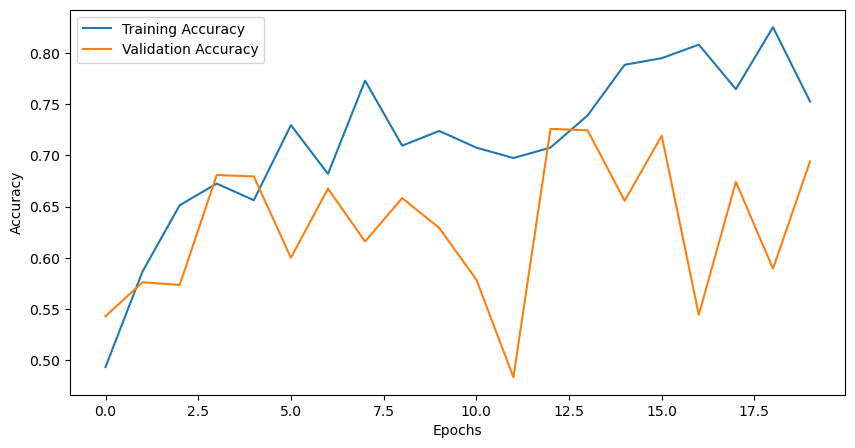

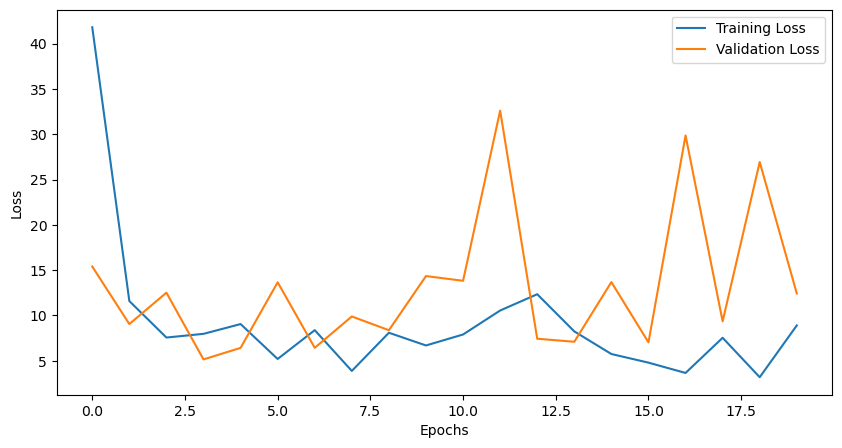

In [21]:
plotAccuracy(history)
plotLoss(history)

The graphs are evidence for some overfitting but also incredibly unstable. There is no consistency but the graphs are able to train and learn across epochs to a fundamental extent. The optimal epoch seems to about 13 as that's where the validation loss diverges and never converges afterwards. We should look at our layer setup and improve it.

# 2.3) Improved Neural Model

---



Previously we investigated into whether the model was able to beat the common sense by using a very vague neural baseline. We will now attempt to improve the stability and performance of the model by adjusting the setup of it.

In [22]:
tf.keras.backend.clear_session()

improvedModel = tf.keras.models.Sequential()
# Retain inputs and scaling as they don't need to be changed
improvedModel.add(tf.keras.layers.Input(shape=(resolution, resolution, 3)))
improvedModel.add(tf.keras.layers.Rescaling(1.0 / 255))

# Utilise Convolutional Nets with Max Pooling
improvedModel.add(tf.keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"))
improvedModel.add(tf.keras.layers.MaxPooling2D((2, 2)))

improvedModel.add(tf.keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"))
improvedModel.add(tf.keras.layers.MaxPooling2D((2, 2)))

improvedModel.add(tf.keras.layers.Conv2D(128, (3, 3), activation="relu", padding="same"))
improvedModel.add(tf.keras.layers.MaxPooling2D((2, 2)))

# Retain our flattening and fully connected classification layer
improvedModel.add(tf.keras.layers.Flatten())
improvedModel.add(tf.keras.layers.Dense(3, activation="softmax"))

improvedModel.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

improvedModel.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 384, 384, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 384, 384, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 192, 192, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 192, 192, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 96, 96, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 96, 96, 128)       7

Our setup has been improved by introduce 3 Convolution blocks. This helps the model 'deep' learn and make much more meaningful neural connections. We've also reduced our total parameter count. We can assume that this is a positive improvement to the model before training as we are cutting out potentially confusing or unneccessary data that the model doesn't need to factor or incorporate.

In [23]:
# Retain our fit parameters, we can't adjust the epoch count lower as at this point we don't know when or where training becomes inneffective
historyImprovedModel = improvedModel.fit(
    trainDataset,
    epochs=20,
    validation_data=valDataset,
    batch_size=batchSize,
    # Incorporate our classweights for stability and better neural understanding of the classes
    class_weight=classWeightsDict,
)

improvedModel.save(str(MODELS_DIR) + "/improvedModel.keras")
improvedModel = tf.keras.models.load_model(str(MODELS_DIR) + "/improvedModel.keras")

Epoch 1/20
83/83 [==============================] - 14s 106ms/step - loss: 1.1123 - accuracy: 0.5859 - val_loss: 0.5347 - val_accuracy: 0.7325
Epoch 2/20
83/83 [==============================] - 8s 89ms/step - loss: 0.4745 - accuracy: 0.8138 - val_loss: 0.3942 - val_accuracy: 0.8596
Epoch 3/20
83/83 [==============================] - 8s 89ms/step - loss: 0.3783 - accuracy: 0.8557 - val_loss: 0.3267 - val_accuracy: 0.8689
Epoch 4/20
83/83 [==============================] - 8s 89ms/step - loss: 0.2094 - accuracy: 0.9214 - val_loss: 0.3625 - val_accuracy: 0.8742
Epoch 5/20
83/83 [==============================] - 8s 89ms/step - loss: 0.1475 - accuracy: 0.9486 - val_loss: 0.2205 - val_accuracy: 0.9086
Epoch 6/20
83/83 [==============================] - 8s 89ms/step - loss: 0.1073 - accuracy: 0.9679 - val_loss: 0.2677 - val_accuracy: 0.9086
Epoch 7/20
83/83 [==============================] - 8s 89ms/step - loss: 0.0548 - accuracy: 0.9826 - val_loss: 0.2701 - val_accuracy: 0.9219
Epoch 8/20


In [24]:
loss, accuracy = improvedModel.evaluate(testDataset, verbose=1)
print(f"Test Loss: {loss:0.4f}")
print(f"Test Accuracy: {accuracy:0.4f}")

12/12 [==============================] - 1s 88ms/step - loss: 0.3560 - accuracy: 0.9372
Test Loss: 0.3560
Test Accuracy: 0.9372


In [25]:
print(getClassificationMetrics(improvedModel, testDataset))

12/12 [==============================] - 0s 22ms/step
Class: Anthracnose
Precision: 0.92
Recall: 1.00
F1-Score: 0.96

Class: FruitFly
Precision: 0.97
Recall: 0.86
F1-Score: 0.91

Class: Healthy
Precision: 0.92
Recall: 0.95
F1-Score: 0.93

Macro Average Precision: 0.94
Macro Average Recall: 0.93
Macro Average F1-Score: 0.93
None


Thats a large improvement over the neural baseline. We've increased our overall accuracy to `93.72%`. However this metric is still overpromising most likely due to overfitting we have not previously addressed.

On a per-class basis, we can see that our metrics have improved but not signifcantly. Our Healthy class is now much more in-line with the metrics of the other oversampled classes and our weighted average has slightly improved. We still need to deal with this imbalance.

Just based on the readings from the training, 20 epochs is a lot for a this neural baseline and it seems to overfit very early on and after 12 epochs it stops any effective training, if we can improve this we can boost the performance and accuracy even higher without having to reduce epochs.

Lets take a look at a graph of the accuracy and loss of the training.

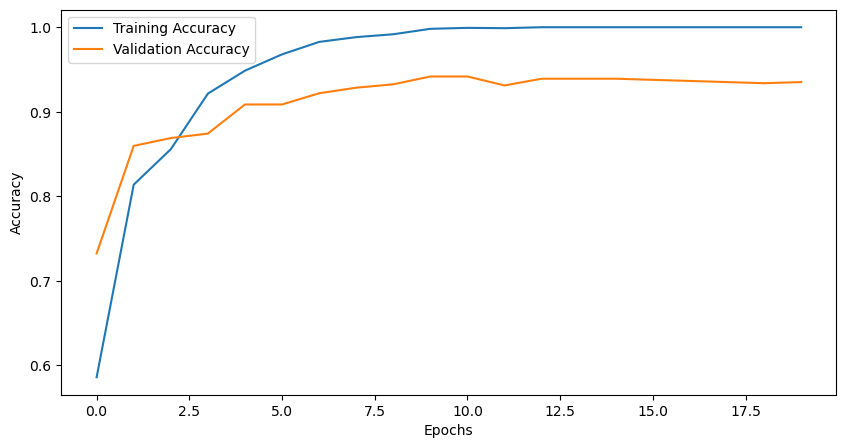

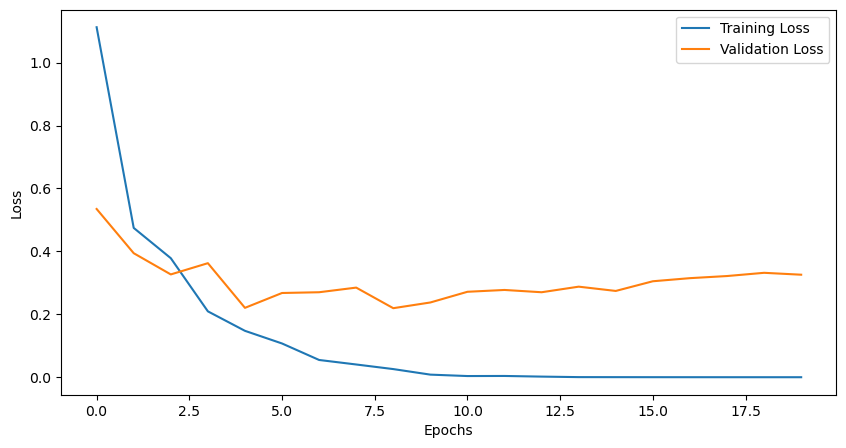

In [26]:
plotAccuracy(historyImprovedModel)
plotLoss(historyImprovedModel)

We have achieved the stability we wanted as our training and validation stays consistent and doesn't change irradically over epochs. Additionally our optimal Epoch is around 2 which further suggests that the model isn't learning properly.

The graphs are evidence for overfitting, we can tell this with accuracy as the model learns more and more about the training set but the validation starts to plateau. As for loss: as training decreases, the validation grows larger. This is not ideal, we want them to both be consistently decreasing.

What we want is for these 2 lines, in both graphs, to be as close in shape as possible to achieve a robust fit.

# **3) OVERFITTING REMEDIED MODEL & EVALUATION**

---



*   Reducing Overfitting through Regularised Layers
*   Further Reduction with L2 & Augmentation





# 3.1) Reducing Overfitting through Regularised Layers

---



The first and more simple way we can help with overfitting is by reworking our layers and hyperparameters

Adding some dropout layers here inbetween every convolution layer will help the model focus more on significant neurons, additonally at the end I add an average pooling combined with an attention mechanism so that the model can understand and map the data better

In [27]:
tf.keras.backend.clear_session()

overfittingRemedy1 = tf.keras.models.Sequential()
# Retain the same input and scaling
overfittingRemedy1.add(tf.keras.layers.Input(shape=(resolution, resolution, 3)))
overfittingRemedy1.add(tf.keras.layers.Rescaling(1.0/255))

overfittingRemedy1.add(tf.keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"))
overfittingRemedy1.add(tf.keras.layers.MaxPooling2D(pool_size=2))
# Add drop out layers to each of the convolution blocks to regularise
overfittingRemedy1.add(tf.keras.layers.Dropout(0.2))

overfittingRemedy1.add(tf.keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"))
overfittingRemedy1.add(tf.keras.layers.MaxPooling2D(pool_size=2))
overfittingRemedy1.add(tf.keras.layers.Dropout(0.2))

overfittingRemedy1.add(tf.keras.layers.Conv2D(128, (3, 3), activation="relu", padding="same"))
overfittingRemedy1.add(tf.keras.layers.MaxPooling2D(pool_size=2))
overfittingRemedy1.add(tf.keras.layers.Dropout(0.2))

overfittingRemedy1.add(tf.keras.layers.Flatten())
overfittingRemedy1.add(tf.keras.layers.Dense(3, activation="softmax"))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
overfittingRemedy1.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

overfittingRemedy1.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_2 (Rescaling)     (None, 384, 384, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 384, 384, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 192, 192, 32)     0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 192, 192, 32)      0         
                                                                 
 conv2d_1 (Conv2D)           (None, 192, 192, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 96, 96, 64)       0         
 2D)                                                    

In [28]:
# Setup our early stopping so we can train until the model thinks its ineffective 
earlyStopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Using early stopping to prove that we have found our optimal epoch
historyOverfittingRemedy1 = overfittingRemedy1.fit(
    trainDataset,
    epochs=40,
    validation_data=valDataset,
    batch_size=batchSize,
    class_weight=classWeightsDict,
    callbacks=[earlyStopping]
)

overfittingRemedy1.save(str(MODELS_DIR) + "/overfittingRemedy1.keras")
overfittingRemedy1 = tf.keras.models.load_model(str(MODELS_DIR) + "/overfittingRemedy1.keras")

Epoch 1/40
83/83 [==============================] - 9s 101ms/step - loss: 1.5173 - accuracy: 0.3461 - val_loss: 1.0698 - val_accuracy: 0.5113
Epoch 2/40
83/83 [==============================] - 8s 100ms/step - loss: 0.8594 - accuracy: 0.5769 - val_loss: 0.8167 - val_accuracy: 0.6199
Epoch 3/40
83/83 [==============================] - 8s 100ms/step - loss: 0.5621 - accuracy: 0.7620 - val_loss: 0.5283 - val_accuracy: 0.7735
Epoch 4/40
83/83 [==============================] - 9s 100ms/step - loss: 0.4802 - accuracy: 0.8104 - val_loss: 0.4397 - val_accuracy: 0.7987
Epoch 5/40
83/83 [==============================] - 8s 100ms/step - loss: 0.3414 - accuracy: 0.8685 - val_loss: 0.2467 - val_accuracy: 0.9020
Epoch 6/40
83/83 [==============================] - 8s 100ms/step - loss: 0.1921 - accuracy: 0.9278 - val_loss: 0.2785 - val_accuracy: 0.8980
Epoch 7/40
83/83 [==============================] - 9s 101ms/step - loss: 0.1268 - accuracy: 0.9573 - val_loss: 0.3419 - val_accuracy: 0.8887
Epoch 

In [29]:
# Evaluate the model on the test dataset
loss, accuracy = overfittingRemedy1.evaluate(testDataset, verbose=1)
print(f"Test Loss: {loss:0.4f}")
print(f"Test Accuracy: {accuracy:0.4f}")

12/12 [==============================] - 1s 37ms/step - loss: 0.2019 - accuracy: 0.9424
Test Loss: 0.2019
Test Accuracy: 0.9424


In [30]:
print(getClassificationMetrics(overfittingRemedy1, testDataset))

12/12 [==============================] - 0s 22ms/step
Class: Anthracnose
Precision: 0.93
Recall: 0.99
F1-Score: 0.96

Class: FruitFly
Precision: 0.93
Recall: 0.94
F1-Score: 0.93

Class: Healthy
Precision: 0.99
Recall: 0.87
F1-Score: 0.93

Macro Average Precision: 0.95
Macro Average Recall: 0.93
Macro Average F1-Score: 0.94
None


Immediate improvements, we can see we never truly hit 1.0000 accuracy but at the same time our validation stays consistent with our training, this seems to show we are not overfitting and the model is training consistently across all epochs. Additionally we've hit a slightly accuracy of `94.24%` compared to the `93.57%` model from before, even though this is a small change I think it's a more accurate rating. This is because our loss has been reduced down to `0.2019` and all our micro scores are closer to `94%`.

Let's have a look at the graphs and verify these improvements.

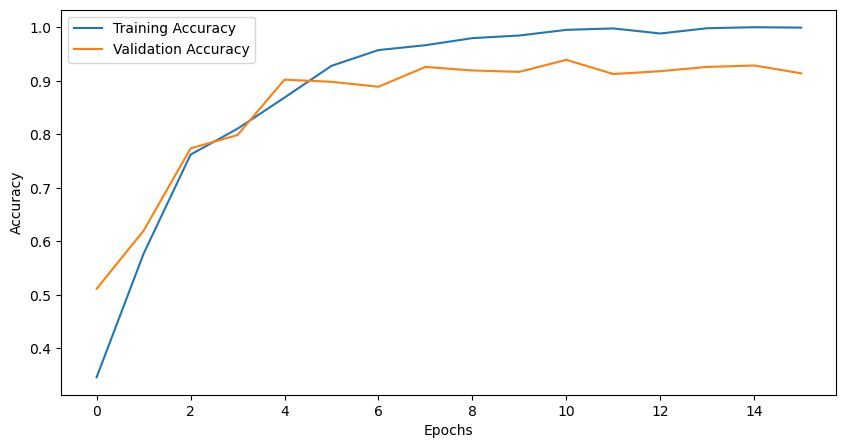

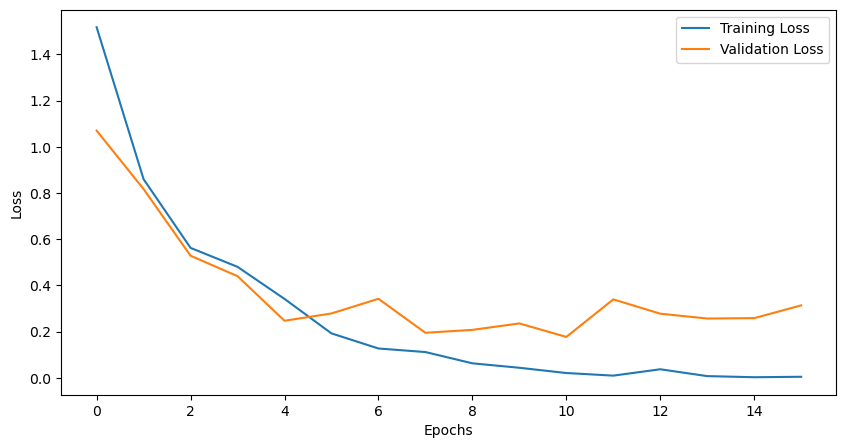

In [31]:
plotAccuracy(historyOverfittingRemedy1)
plotLoss(historyOverfittingRemedy1)

The graphs illustrate that we have aided some of the overfitting symptoms. However it is not a robust fit either. The model is marginally overfitting - not in the sense that the model fails to generalise underlying patterns, but due to the model not being not quite precisely tuned to generalise.
This is demonstrated by the validation loss being consistently lower than the training loss and the validation accuracy being higher than training. We can also assume that the optimal Epoch is about 5. At this poin training and validation converge and overfitting happens afterwards.

It seems we have struck a mostly stable model but we still have some room for improvement involving further regularisation and epoch analysis.

# 3.2) Further Reduction with L2 & Augmentation

---



We will now look at some further techniques like L2 and Augmentation to aid the overfitting further.

The dataset source states that the data has already been through a preprocess enhancement where the sample count has been increased through augmentation, however we will test to see if further augmentation can improve the model.

In [16]:
tf.keras.backend.clear_session()

# Define the data augmentation layer
augLayer = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.1)
])

overfittingRemedy2 = tf.keras.models.Sequential()

# Input layer
overfittingRemedy2.add(tf.keras.layers.Input(shape=(resolution, resolution, 3)))
# Additonal data augmentation layer
overfittingRemedy2.add(augLayer)
overfittingRemedy2.add(tf.keras.layers.Rescaling(1.0 / 255))

overfittingRemedy2.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation="relu",))
overfittingRemedy2.add(tf.keras.layers.MaxPooling2D(pool_size=2))
overfittingRemedy2.add(tf.keras.layers.Dropout(0.2))

overfittingRemedy2.add(tf.keras.layers.Conv2D(filters=64, kernel_size=3, activation="relu"))
overfittingRemedy2.add(tf.keras.layers.MaxPooling2D(pool_size=2))
overfittingRemedy2.add(tf.keras.layers.Dropout(0.2))

overfittingRemedy2.add(tf.keras.layers.Conv2D(filters=128, kernel_size=3, activation="relu"))
overfittingRemedy2.add(tf.keras.layers.MaxPooling2D(pool_size=2))
overfittingRemedy2.add(tf.keras.layers.Dropout(0.2))

# Global Average Pooling
overfittingRemedy2.add(tf.keras.layers.GlobalAveragePooling2D())
# Attention mechanism with dropout instead of flattening
overfittingRemedy2.add(tf.keras.layers.Dense(128, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.01)))
overfittingRemedy2.add(tf.keras.layers.Dropout(0.3))
overfittingRemedy2.add(tf.keras.layers.Dense(3, activation="softmax"))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
overfittingRemedy2.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

overfittingRemedy2.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (None, 384, 384, 3)       0         
                                                                 
 rescaling (Rescaling)       (None, 384, 384, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 382, 382, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 191, 191, 32)     0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 191, 191, 32)      0         
                                                                 
 conv2d_1 (Conv2D)           (None, 189, 189, 64)      18496     
                                                      

We've added L2 to the end along with a dropout, this removes the need for the high parameter flattening from before, this reduces our total parameter count by nearly 10x. We also involve an augmentation layer right before the rescaling.

*NOTE: From here forwards TF will keep mentioning a 'WARNING' this is to do with the augmentation layer, it does not affect the model, only just how fast the model trains.*

In [17]:
# Setup our early stopping
earlyStopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Using early stopping to prove that we have found our optimal epoch
historyOverfittingRemedy2 = overfittingRemedy2.fit(
    trainDataset,
    epochs=40,
    validation_data=valDataset,
    batch_size=batchSize,
    class_weight=classWeightsDict,
    callbacks=[earlyStopping]
)

overfittingRemedy2.save(str(MODELS_DIR) + "/overfittingRemedy2.keras")
overfittingRemedy2 = tf.keras.models.load_model(str(MODELS_DIR) + "/overfittingRemedy2.keras")

Epoch 1/40
83/83 [==============================] - 33s 295ms/step - loss: 1.6421 - accuracy: 0.4552 - val_loss: 1.1308 - val_accuracy: 0.5060
Epoch 2/40
83/83 [==============================] - 23s 275ms/step - loss: 0.9027 - accuracy: 0.6150 - val_loss: 0.7781 - val_accuracy: 0.6384
Epoch 3/40
83/83 [==============================] - 23s 276ms/step - loss: 0.6874 - accuracy: 0.7303 - val_loss: 0.5645 - val_accuracy: 0.8384
Epoch 4/40
83/83 [==============================] - 23s 277ms/step - loss: 0.6061 - accuracy: 0.7680 - val_loss: 0.5159 - val_accuracy: 0.8583
Epoch 5/40
83/83 [==============================] - 23s 275ms/step - loss: 0.4909 - accuracy: 0.8319 - val_loss: 0.4628 - val_accuracy: 0.8570
Epoch 6/40
83/83 [==============================] - 23s 274ms/step - loss: 0.4405 - accuracy: 0.8557 - val_loss: 0.6290 - val_accuracy: 0.7457
Epoch 7/40
83/83 [==============================] - 23s 275ms/step - loss: 0.3868 - accuracy: 0.8670 - val_loss: 0.3353 - val_accuracy: 0.8967

In [22]:
loss, accuracy = overfittingRemedy2.evaluate(testDataset, verbose=1)
print(f"Test Loss: {loss:0.4f}")
print(f"Test Accuracy: {accuracy:0.4f}")

12/12 [==============================] - 1s 35ms/step - loss: 0.2003 - accuracy: 0.9529
Test Loss: 0.2003
Test Accuracy: 0.9529


In [19]:
print(getClassificationMetrics(overfittingRemedy2, testDataset))

12/12 [==============================] - 0s 22ms/step
Class: Anthracnose
Precision: 0.9563
Recall: 0.9808
F1-Score: 0.9684

Class: FruitFly
Precision: 0.9462
Recall: 0.9318
F1-Score: 0.9389

Class: Healthy
Precision: 0.9565
Recall: 0.9362
F1-Score: 0.9462

Macro Average Precision: 0.9530
Macro Average Recall: 0.9496
Macro Average F1-Score: 0.9512
None


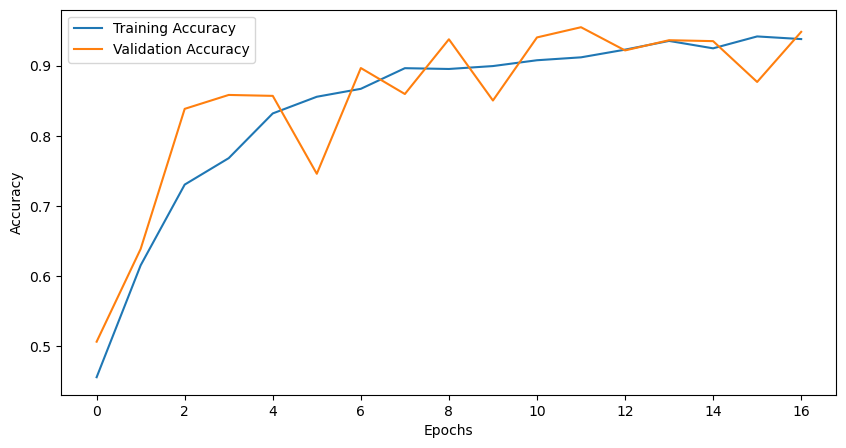

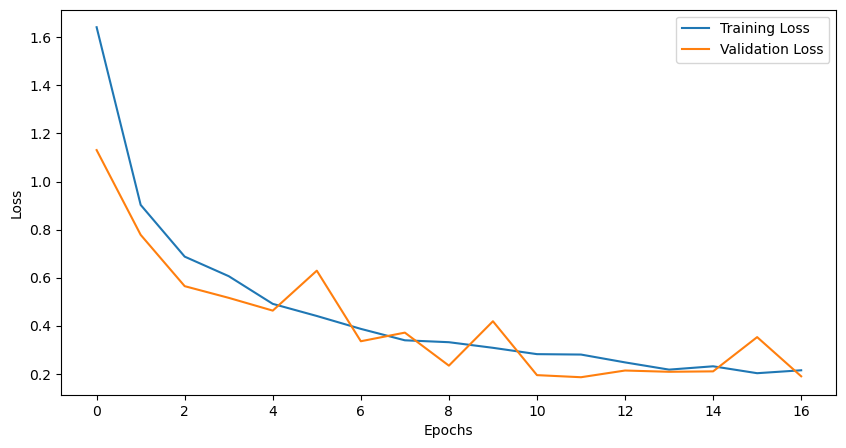

In [20]:
plotAccuracy(historyOverfittingRemedy2)
plotLoss(historyOverfittingRemedy2)

Another improvement! L2 and Augmentation has improved the model's accuracy, we are now averaging around `95%` in all metrics. This is an extremely strong model however if we look at our model our aggressive regularisation and augmentation has caused the model to slightly underfit. This can be fine tuned into a further robust fit with hyperparameter tweaking to find the best values. Additonally some of the instability can be ironed out by adapting the batchSize and learningRate, however this is something we will tweak nearer to the final model. 

Our model now also has a meaningful amount of training across many epochs which is a good sign that the model isn't overfitting.

# **4) SYSTEMATIC HYPERPARAMETER FINE TUNING**

---



*   Establishing focal hyperparameters
*   Exploring significant hyperparameters
*   Using the optimal values





# 4.1) Establishing focal hyperparameters

---



In order to ensure our systematic tuning isn't focusing on variables that don't make differences or we know the ground truth to their results, we will define what we will be looking to test and create permutations of.

For now we don't truly know the effects of every parameter and doing an exhaustive search takes far too much computational power and time that we don't have. Instead we will try to narrow the amount of exhaustive permutations by doing doing random selections over a limited amount of times and analyse where accuracy and permutative values are related.

In [13]:
learnRates = [0.001]
dropRates = [0.15, 0.2, 0.25]
kernelRegs = [0.01, 0.015, 0.02]
kernelSizes = [2,3,4]
poolSizes = [2,3,4]
augmentations = [0.1,0.2,0.3]

Using our remedied model, we will craft a template function that will create and return a model using function parameters to alter the hyperparams.

In [18]:
def hyperparamModel (learnRate, dropRate, kernelReg, kernelSize, poolSize, augmentation):
    augLayer = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal_and_vertical"),
        tf.keras.layers.RandomRotation(augmentation),
        # Half the rotation for the zoom
        tf.keras.layers.RandomZoom(augmentation / 2)
    ])
    hyperparamModel = tf.keras.models.Sequential()
    hyperparamModel.add(tf.keras.layers.Input(shape=(resolution, resolution, 3)))
    hyperparamModel.add(augLayer)
    hyperparamModel.add(tf.keras.layers.Rescaling(1.0 / 255))
    hyperparamModel.add(tf.keras.layers.Conv2D(filters=32, kernel_size=kernelSize, activation="relu",))
    hyperparamModel.add(tf.keras.layers.MaxPooling2D(pool_size=2))
    hyperparamModel.add(tf.keras.layers.Dropout(dropRate))
    hyperparamModel.add(tf.keras.layers.Conv2D(filters=64, kernel_size=kernelSize, activation="relu"))
    hyperparamModel.add(tf.keras.layers.MaxPooling2D(pool_size=2))
    hyperparamModel.add(tf.keras.layers.Dropout(dropRate))
    hyperparamModel.add(tf.keras.layers.Conv2D(filters=128, kernel_size=kernelSize, activation="relu"))
    hyperparamModel.add(tf.keras.layers.MaxPooling2D(pool_size=2))
    hyperparamModel.add(tf.keras.layers.Dropout(dropRate))
    hyperparamModel.add(tf.keras.layers.GlobalAveragePooling2D())
    hyperparamModel.add(tf.keras.layers.Dense(128, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(kernelReg)))
    # Bump the droprate a bit higher to match the remedy model
    hyperparamModel.add(tf.keras.layers.Dropout(dropRate + 0.1))
    hyperparamModel.add(tf.keras.layers.Dense(3, activation="softmax"))
    optimizer = tf.keras.optimizers.Adam(learning_rate=learnRate)
    hyperparamModel.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return hyperparamModel

Testing configuration #1/20: lr:0.001 dr:0.15 kr:0.01 ks:3 ps:2 ag:0.1
Epoch 1/5
83/83 [==============================] - 26s 277ms/step - loss: 1.6137 - accuracy: 0.4730 - val_loss: 1.1631 - val_accuracy: 0.4570
Epoch 2/5
83/83 [==============================] - 23s 274ms/step - loss: 0.8968 - accuracy: 0.6033 - val_loss: 0.7898 - val_accuracy: 0.5921
Epoch 3/5
83/83 [==============================] - 23s 274ms/step - loss: 0.6806 - accuracy: 0.7193 - val_loss: 0.6205 - val_accuracy: 0.7682
Epoch 4/5
83/83 [==============================] - 23s 276ms/step - loss: 0.5714 - accuracy: 0.7941 - val_loss: 0.5462 - val_accuracy: 0.8000
Epoch 5/5
12/12 [==============================] - 1s 36ms/step - loss: 0.4629 - accuracy: 0.8455
Testing configuration #2/20: lr:0.001 dr:0.2 kr:0.015 ks:3 ps:2 ag:0.3
Epoch 1/5
83/83 [==============================] - 26s 285ms/step - loss: 2.0095 - accuracy: 0.4363 - val_loss: 1.2923 - val_accuracy: 0.5841
Epoch 2/5
83/83 [==============================] -

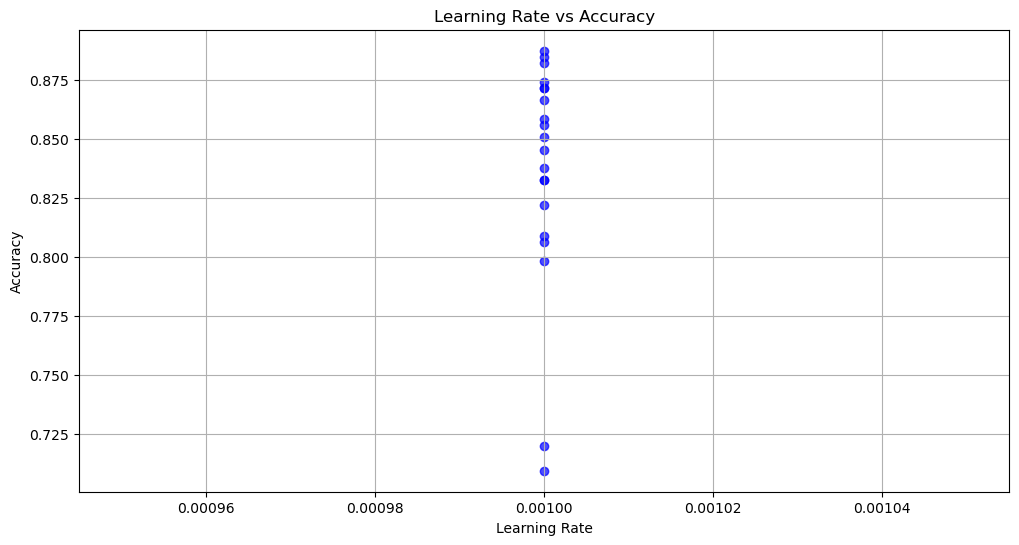

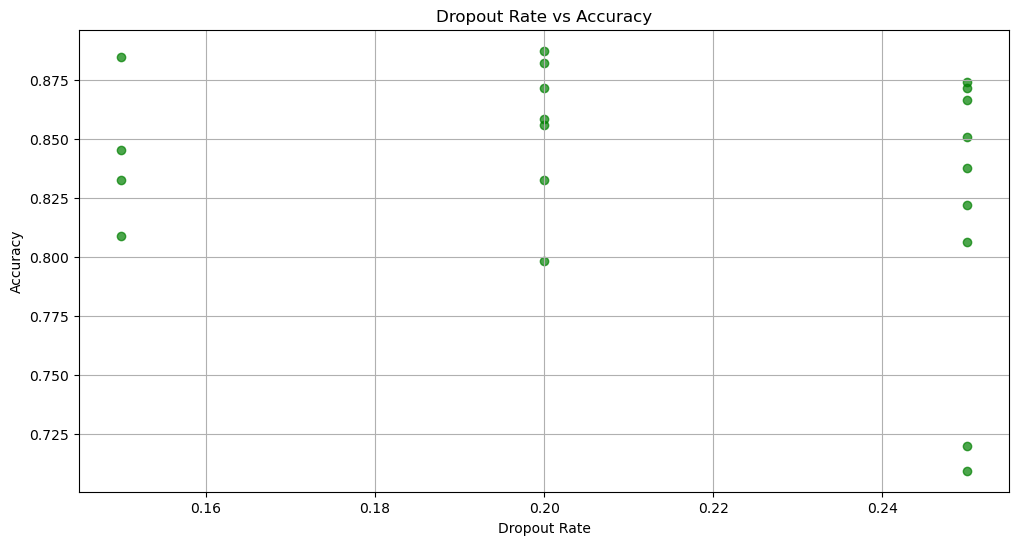

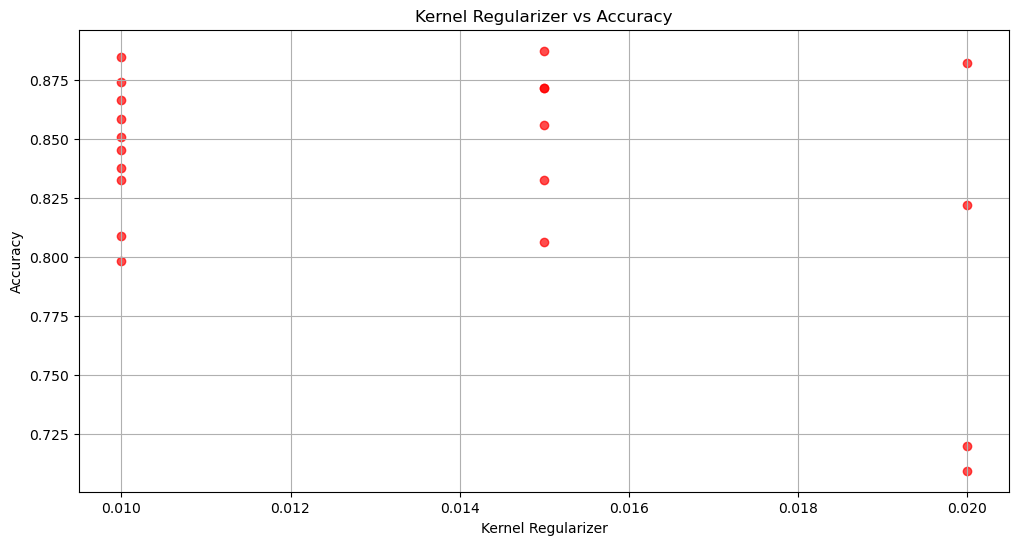

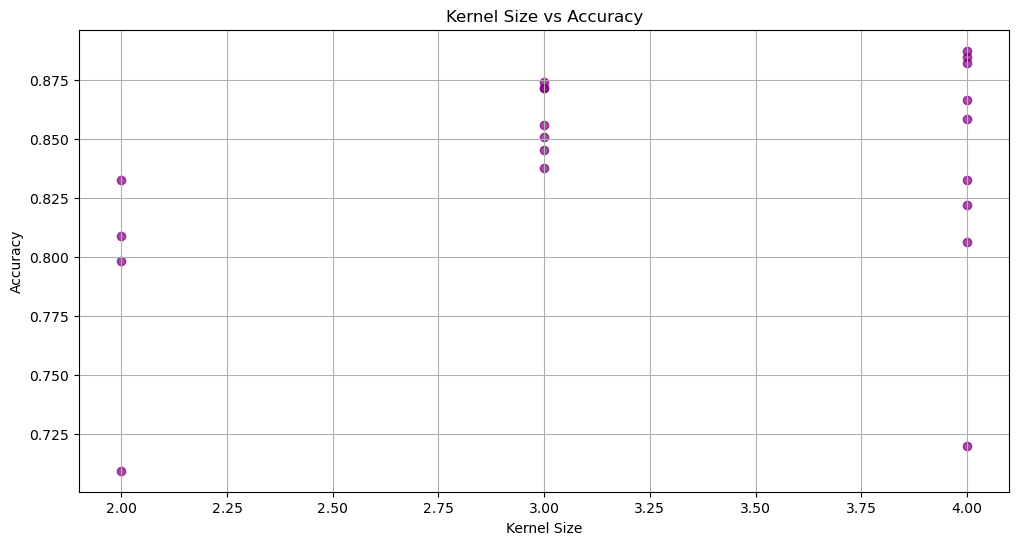

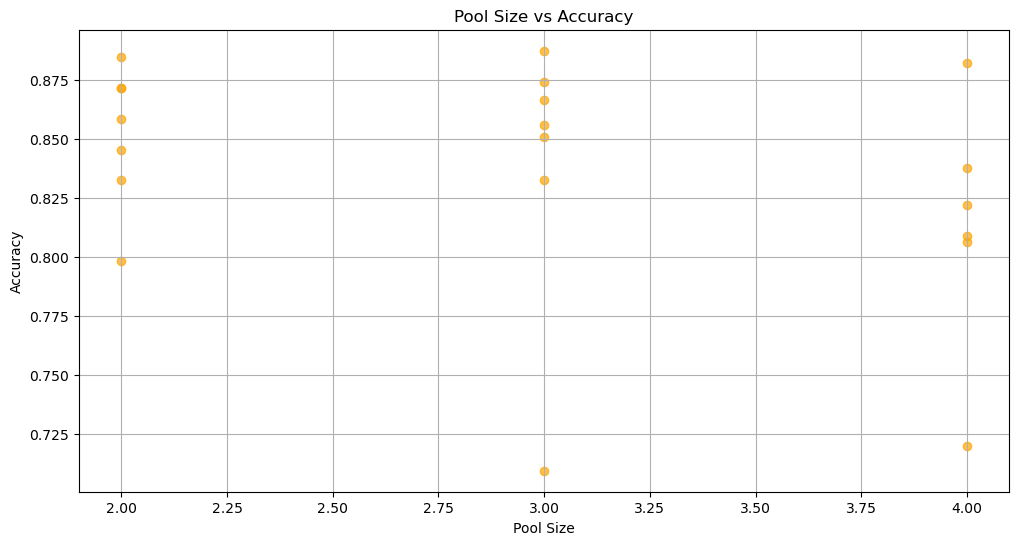

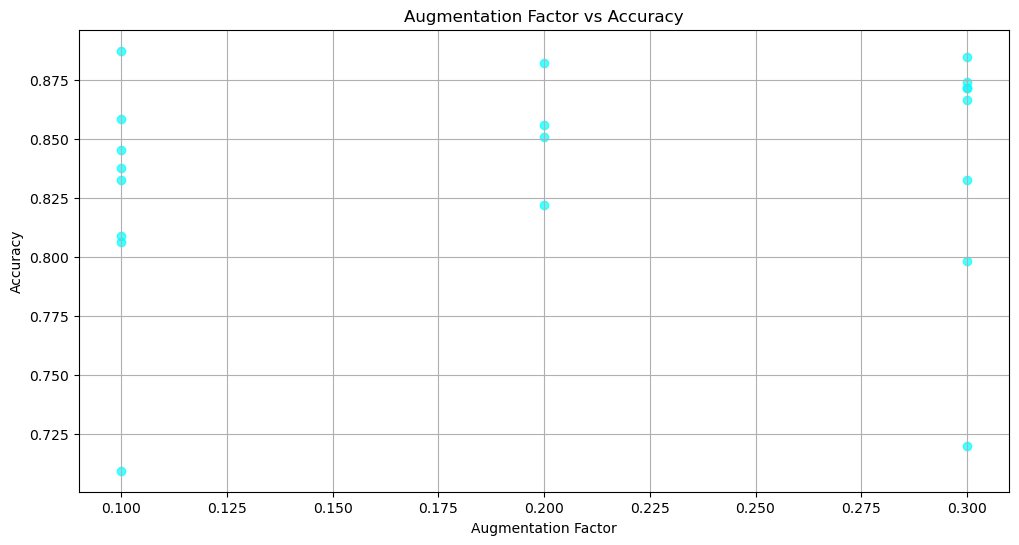

In [16]:
# An array to store our experimental values
results = []
# Determines how many times we want to run our permutations
permutationLength = 20

for i in range (0, permutationLength):
    lr = random.choice(learnRates)
    dr = random.choice(dropRates)
    kr = random.choice(kernelRegs)
    ks = random.choice(kernelSizes)
    ps = random.choice(poolSizes)
    ag = random.choice(augmentations)
    
    permutationString = (f"Testing configuration #{i + 1}/{permutationLength}: lr:{lr} dr:{dr} kr:{kr} ks:{ks} ps:{ps} ag:{ag}")
    print(permutationString)
    
    tf.keras.backend.clear_session()
    model = hyperparamModel(lr, dr, kr, ks, ps, ag)

    history = model.fit(
        trainDataset,
        # Approximately 5 epochs is roughly enough to guarantee a training accuracy in the 70-85 range
        # Epochs after this exponentially reduce the delta between accuracies, therefore 5 epochs is used to yeild computational efficiency
        epochs=5,
        validation_data=valDataset,
        batch_size=batchSize,
        class_weight=classWeightsDict,
    )
    
    # Evaluate on validation set to get a general accuracy and loss
    loss, accuracy = model.evaluate(testDataset, verbose=1)
    
    # Append results to the array
    results.append({
        "permutation": permutationString,
        "lr": lr,
        "dr": dr,
        "kr": kr,
        "ks": ks,
        "ps": ps,
        "ag": ag,
        "accuracy": accuracy,
        "loss": loss
    })

# Create a dataframe of the results
resultsDF = pd.DataFrame(results)

# Sort by accuracy
resultsDF = resultsDF.sort_values(by="accuracy", ascending=False)
print(resultsDF.head())

# Save to CSV for manual inspection
resultsDF.to_csv("hyperparameterResults1.csv", index=False)

Based on reading the train log, the highest accuracy was recorded at `88.74%` with the permutation:
lr:0.001 dr:0.2 kr:0.015 ks:4 ps:3 ag:0.1
The lowest accuracy was recorded at `70.94%` with the permutation:
lr:0.001 dr:0.25 kr:0.02 ks:2 ps:3 ag:0.1

We can further investigate this in a more efficient manner by visualizing the data and also getting averages for each of the random permutations:

In [69]:
def printScatterAverages(DF, variable):
    # Takes our dataframe and the target variable and prints the mean value
    print(DF.groupby(variable)[["accuracy", "loss"]].mean())

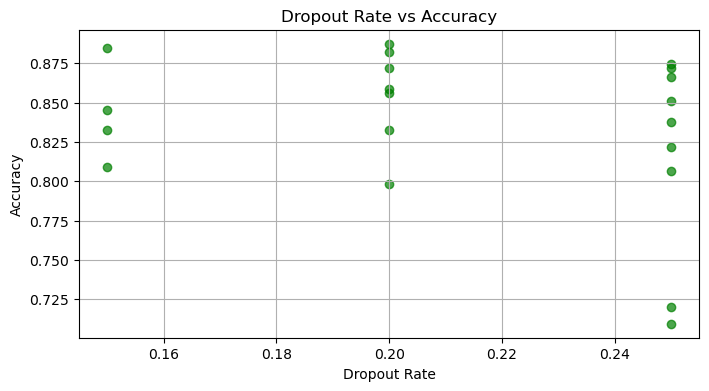

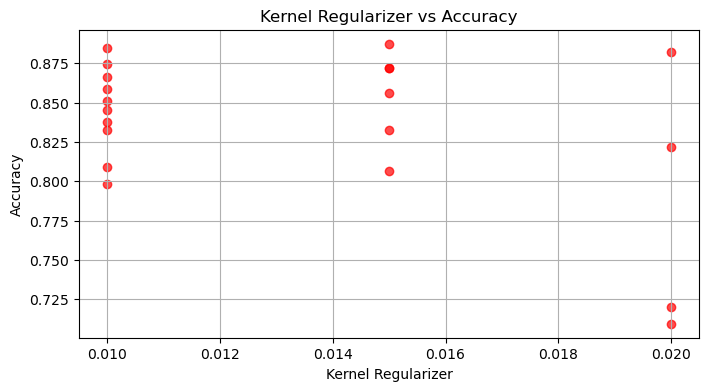

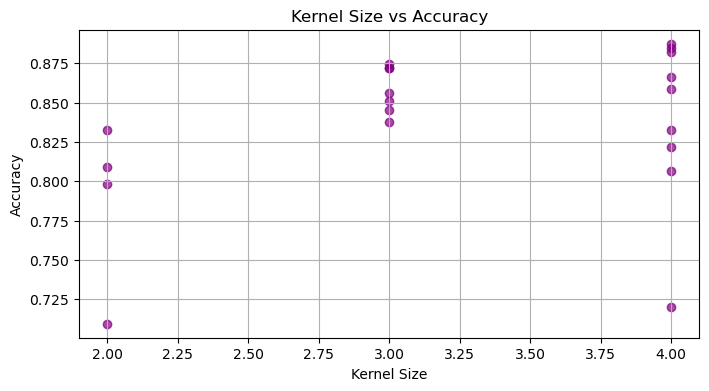

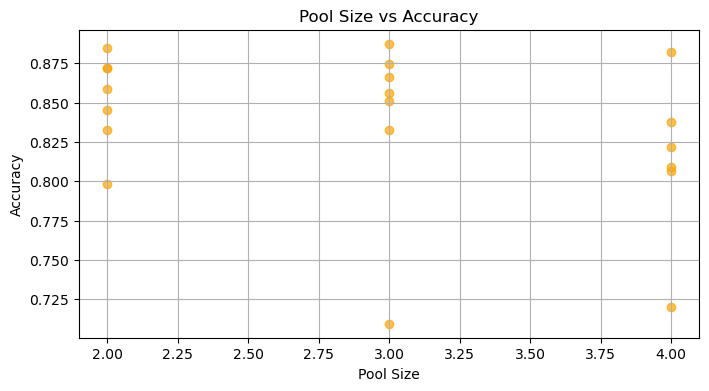

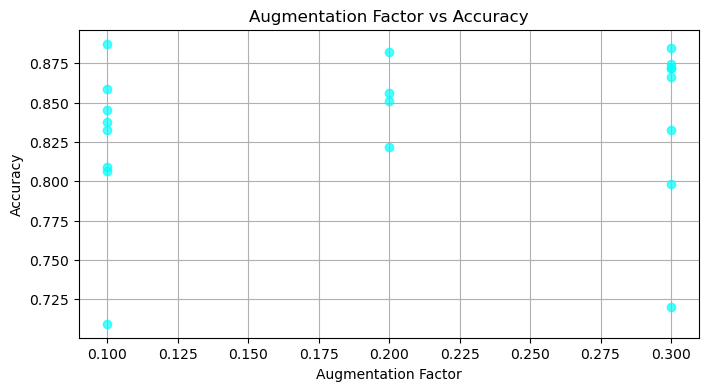

In [25]:
# Scatter plots of the hyperparameters vs accuracy
plt.figure(figsize=(8, 4))
plt.scatter(resultsDF["dr"], resultsDF["accuracy"], alpha=0.7, color="green")
plt.title("Dropout Rate vs Accuracy")
plt.xlabel("Dropout Rate")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.scatter(resultsDF["kr"], resultsDF["accuracy"], alpha=0.7, color="red")
plt.title("Kernel Regularizer vs Accuracy")
plt.xlabel("Kernel Regularizer")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.scatter(resultsDF["ks"], resultsDF["accuracy"], alpha=0.7, color="purple")
plt.title("Kernel Size vs Accuracy")
plt.xlabel("Kernel Size")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.scatter(resultsDF["ps"], resultsDF["accuracy"], alpha=0.7, color="orange")
plt.title("Pool Size vs Accuracy")
plt.xlabel("Pool Size")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.scatter(resultsDF["ag"], resultsDF["accuracy"], alpha=0.7, color="cyan")
plt.title("Augmentation Factor vs Accuracy")
plt.xlabel("Augmentation Factor")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

The way we can interpret these graphs is by looking at vertical distribution of the permuations of each variable, if they are clustered at the same accuracies for each permutation, we can infer that changes to those variables are insignifcant, conversely for clusters that move lower or higher accuracies. This is good for us to know which permutations may have outliers due to over or undersampling, however instead of guessing we can just get the true averages by calling the function we made earlier:

In [37]:
printScatterAverages(resultsDF, "dr")
printScatterAverages(resultsDF, "kr")
printScatterAverages(resultsDF, "ks")
printScatterAverages(resultsDF, "ps")
printScatterAverages(resultsDF, "ag")

      accuracy      loss
dr                      
0.15  0.842932  0.493616
0.20  0.855273  0.467359
0.25  0.817627  0.544551
       accuracy      loss
kr                       
0.010  0.845812  0.490320
0.015  0.854276  0.473825
0.020  0.783377  0.600196
    accuracy      loss
ks                    
2   0.787304  0.600560
3   0.858265  0.456400
4   0.840023  0.505544
    accuracy      loss
ps                    
2   0.851907  0.480734
3   0.839566  0.479299
4   0.812827  0.571117
     accuracy      loss
ag                     
0.1  0.823298  0.522807
0.2  0.852749  0.456011
0.3  0.839987  0.517554


From these averages we can assume that:
- poolSize seems to be most effective at around 2, we can't reduce this lower as it will just make the model more complex.
- augmentation does not make a significant difference, this is evidenced by the ranging values across all permutations however from this test our ideal value is 0.2.
- kernelSize is extremely sensitive and is a large driving factor in accuracy. An accuracy of 3 seems like an ideal match, this is evidenced by averages although if we have a look at the top 3 (including #1), they all have a kernelSize of 4. This is probably due to the amount of deviation between configurations, therefore we may consider them as outliers. We can try to see if increasing the kernelSize decreases the accuracy to determine whether or not 4 is truly the ideal size.
- dropoutRate & kernelRegulariser are sensitive in the 0.15->0.20 and 0.010->0.015 range respectively. Due to the lack of samples, we can only make broad conclusions. We can assume that the larger the number the worse it will perform, therefore we need to use lower values to find out more about where it becomes less accurate.

Therefore for our next systematic test we will run further permutations on dropoutRate, kernelSize & kernalRegulariser to find the largest yeilding respective values whilst also investigating any relationships between all 3.

# 4.2) Exploring significant hyperparameters

---



Previously we had done some random permutative tests to figure out if we could find any significance for each hyperparameter, we will now explore the selected few in a more granual and exhaustive detail.

In [46]:
learnRates = [0.001]
# Investigate whether 0.2 is where the optimal value may lie
dropRates = [0.1, 0.14, 0.18]
# Investigate on a slightly more granualar level
kernelRegs = [0.01, 0.013, 0.016]
# Investigate whether 4 is truly after the apex
kernelSizes = [4, 6, 8]
poolSizes = [2]
augmentations = [0.2]

In [47]:
results2 = []
# Counter to track progress (Takes an hour or so on good hardware)
count = 0
for i in range (0, len(dropRates)):
    for j in range (0, len(kernelRegs)):
        for k in range (0, len(kernelSizes)):
            count += 1
            lr = learnRates[0]
            dr = dropRates[i]
            kr = kernelRegs[j]
            ks = kernelSizes[k]
            ps = poolSizes[0]
            ag = augmentations[0]
            
            permutationString = (f"Testing configuration #{count}: lr:{lr} dr:{dr} kr:{kr} ks:{ks} ps:{ps} ag:{ag}")
            print(permutationString)
            
            tf.keras.backend.clear_session()
            model = hyperparamModel(lr, dr, kr, ks, ps, ag)
        
            history = model.fit(
                trainDataset,
                epochs=5,
                validation_data=valDataset,
                batch_size=batchSize,
                class_weight=classWeightsDict,
            )
            
            loss, accuracy = model.evaluate(testDataset, verbose=1)
            results.append({
                "permutation": permutationString,
                "lr": lr,
                "dr": dr,
                "kr": kr,
                "ks": ks,
                "ps": ps,
                "ag": ag,
                "accuracy": accuracy,
                "loss": loss
            })

resultsDF2 = pd.DataFrame(results)

# Sort by accuracy
resultsDF2 = resultsDF2.sort_values(by="accuracy", ascending=False)
print(resultsDF2.head())

# Save to CSV for manual inspection
resultsDF2.to_csv("hyperparameterResults2.csv", index=False)

Testing configuration #1: lr:0.001 dr:0.1 kr:0.01 ks:4 ps:2 ag:0.2
Epoch 1/5
83/83 [==============================] - 30s 326ms/step - loss: 1.6354 - accuracy: 0.4405 - val_loss: 1.0306 - val_accuracy: 0.6305
Epoch 2/5
83/83 [==============================] - 26s 305ms/step - loss: 0.8470 - accuracy: 0.6562 - val_loss: 0.7124 - val_accuracy: 0.7510
Epoch 3/5
83/83 [==============================] - 26s 307ms/step - loss: 0.6259 - accuracy: 0.7771 - val_loss: 0.5088 - val_accuracy: 0.8503
Epoch 4/5
83/83 [==============================] - 25s 303ms/step - loss: 0.5629 - accuracy: 0.7900 - val_loss: 0.4148 - val_accuracy: 0.8861
Epoch 5/5
12/12 [==============================] - 1s 98ms/step - loss: 0.3672 - accuracy: 0.8822
Testing configuration #2: lr:0.001 dr:0.1 kr:0.01 ks:6 ps:2 ag:0.2
Epoch 1/5
83/83 [==============================] - 36s 369ms/step - loss: 1.5532 - accuracy: 0.5028 - val_loss: 1.0500 - val_accuracy: 0.5603
Epoch 2/5
83/83 [==============================] - 28s 336

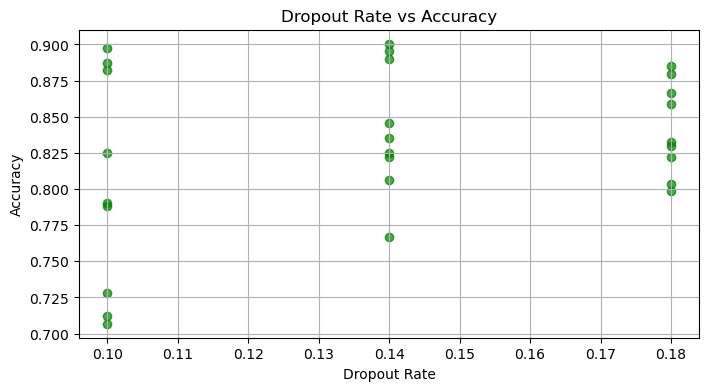

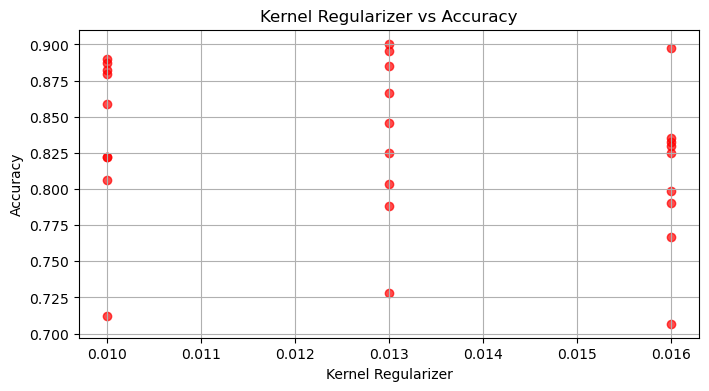

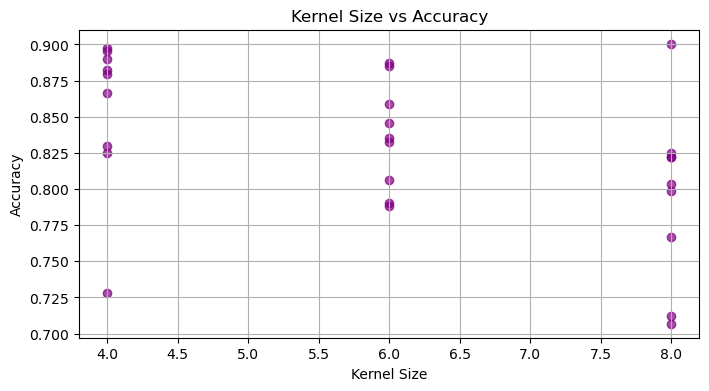

In [48]:
plt.figure(figsize=(8, 4))
plt.scatter(resultsDF2["dr"], resultsDF2["accuracy"], alpha=0.7, color="green")
plt.title("Dropout Rate vs Accuracy")
plt.xlabel("Dropout Rate")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.scatter(resultsDF2["kr"], resultsDF2["accuracy"], alpha=0.7, color="red")
plt.title("Kernel Regularizer vs Accuracy")
plt.xlabel("Kernel Regularizer")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.scatter(resultsDF2["ks"], resultsDF2["accuracy"], alpha=0.7, color="purple")
plt.title("Kernel Size vs Accuracy")
plt.xlabel("Kernel Size")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

In [49]:
printScatterAverages(resultsDF2, "dr")
printScatterAverages(resultsDF2, "kr")
printScatterAverages(resultsDF2, "ks")

      accuracy      loss
dr                      
0.10  0.801920  0.520652
0.14  0.842932  0.469624
0.18  0.841768  0.467662
       accuracy      loss
kr                       
0.010  0.840023  0.488583
0.013  0.837405  0.471727
0.016  0.809191  0.497628
    accuracy      loss
ks                    
4   0.854857  0.457112
6   0.836533  0.461214
8   0.795230  0.539612


We ran 3^3 permutations and we've found some conclusive results.

- The kernelSizes have a negative correlation, previously I had made an assumption that if we increased it we could find where the optimal value might lie and we can confirm that the optimal value is at 3 and not 4.
- The ideal kernelReg is about 0.013, although the accuracy is fractionally smaller than 0.010, it has a slightly lower loss which means its slightly better at generalizing. Also from our previous tests 0.015 was the ideal kernelReg so it would be in-line with our findings. 
- The ideal dropRate from this test is around 0.18, 0.14 and 0.18 share virtually the same accuracy and loss on average however 0.18 would be a more ideal figure as the samples are well clustered with no outliers.

We can conclude this section with the optimal hyperparameters that were found from both tests:

- dropRate = 0.18
- kernelReg = 0.013
- kernelSize = 3
- poolSize = 2
- augmentation = 0.2

# 4.3) Using the optimal values

---



Now that we have investigated the model hyperparameters, we will apply the tweaked values to the model and compare it to the model's performance from 3.2

In [64]:
tf.keras.backend.clear_session()

augLayer = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.1)
])

fineTuned = tf.keras.models.Sequential()

fineTuned.add(tf.keras.layers.Input(shape=(resolution, resolution, 3)))
fineTuned.add(augLayer)
fineTuned.add(tf.keras.layers.Rescaling(1.0 / 255))

fineTuned.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation="relu",))
fineTuned.add(tf.keras.layers.MaxPooling2D(pool_size=2))
fineTuned.add(tf.keras.layers.Dropout(0.18))

fineTuned.add(tf.keras.layers.Conv2D(filters=64, kernel_size=3, activation="relu"))
fineTuned.add(tf.keras.layers.MaxPooling2D(pool_size=2))
fineTuned.add(tf.keras.layers.Dropout(0.18))

fineTuned.add(tf.keras.layers.Conv2D(filters=128, kernel_size=3, activation="relu"))
fineTuned.add(tf.keras.layers.MaxPooling2D(pool_size=2))
fineTuned.add(tf.keras.layers.Dropout(0.18))

fineTuned.add(tf.keras.layers.GlobalAveragePooling2D())
fineTuned.add(tf.keras.layers.Dense(128, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.013)))
fineTuned.add(tf.keras.layers.Dropout(0.28))
fineTuned.add(tf.keras.layers.Dense(3, activation="softmax"))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
fineTuned.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

fineTuned.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (None, 384, 384, 3)       0         
                                                                 
 rescaling (Rescaling)       (None, 384, 384, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 382, 382, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 191, 191, 32)     0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 191, 191, 32)      0         
                                                                 
 conv2d_1 (Conv2D)           (None, 189, 189, 64)      18496     
                                                      

In [65]:
earlyStopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

historyFineTuned = fineTuned.fit(
    trainDataset,
    epochs=40,
    validation_data=valDataset,
    batch_size=batchSize,
    class_weight=classWeightsDict,
    callbacks=[earlyStopping]
)

fineTuned.save(str(MODELS_DIR) + "/fineTuned.keras")
fineTuned = tf.keras.models.load_model(str(MODELS_DIR) + "/fineTuned.keras")

Epoch 1/40
83/83 [==============================] - 28s 303ms/step - loss: 1.7662 - accuracy: 0.4809 - val_loss: 1.0237 - val_accuracy: 0.6887
Epoch 2/40
83/83 [==============================] - 25s 296ms/step - loss: 0.8219 - accuracy: 0.6513 - val_loss: 0.6958 - val_accuracy: 0.7550
Epoch 3/40
83/83 [==============================] - 26s 311ms/step - loss: 0.6758 - accuracy: 0.7023 - val_loss: 0.6169 - val_accuracy: 0.7788
Epoch 4/40
83/83 [==============================] - 25s 297ms/step - loss: 0.5590 - accuracy: 0.7756 - val_loss: 0.4675 - val_accuracy: 0.8649
Epoch 5/40
83/83 [==============================] - 25s 296ms/step - loss: 0.4890 - accuracy: 0.8251 - val_loss: 0.4480 - val_accuracy: 0.8490
Epoch 6/40
83/83 [==============================] - 25s 298ms/step - loss: 0.4581 - accuracy: 0.8311 - val_loss: 0.5850 - val_accuracy: 0.8053
Epoch 7/40
83/83 [==============================] - 25s 298ms/step - loss: 0.3747 - accuracy: 0.8742 - val_loss: 0.3595 - val_accuracy: 0.8728

In [66]:
loss, accuracy = fineTuned.evaluate(testDataset, verbose=1)
print(f"Test Loss: {loss:0.4f}")
print(f"Test Accuracy: {accuracy:0.4f}")

12/12 [==============================] - 1s 36ms/step - loss: 0.1774 - accuracy: 0.9581
Test Loss: 0.1774
Test Accuracy: 0.9581


In [67]:
print(getClassificationMetrics(fineTuned, testDataset))

12/12 [==============================] - 0s 24ms/step
Class: Anthracnose
Precision: 1.0000
Recall: 0.9359
F1-Score: 0.9669

Class: FruitFly
Precision: 0.8919
Recall: 1.0000
F1-Score: 0.9429

Class: Healthy
Precision: 1.0000
Recall: 0.9362
F1-Score: 0.9670

Macro Average Precision: 0.9640
Macro Average Recall: 0.9574
Macro Average F1-Score: 0.9589
None


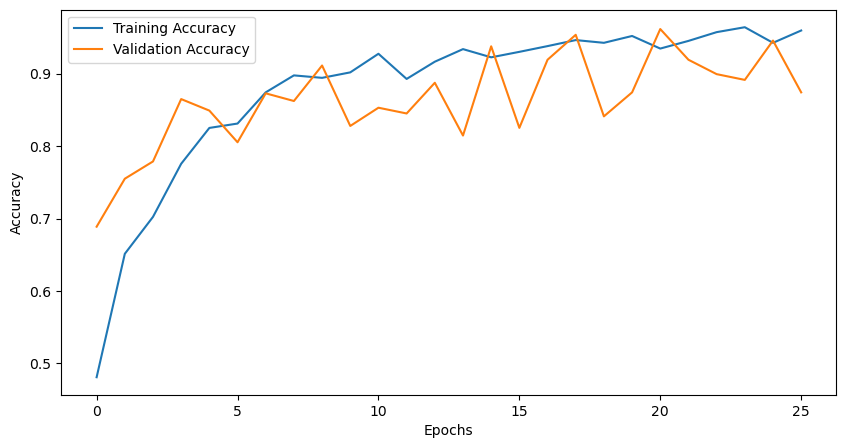

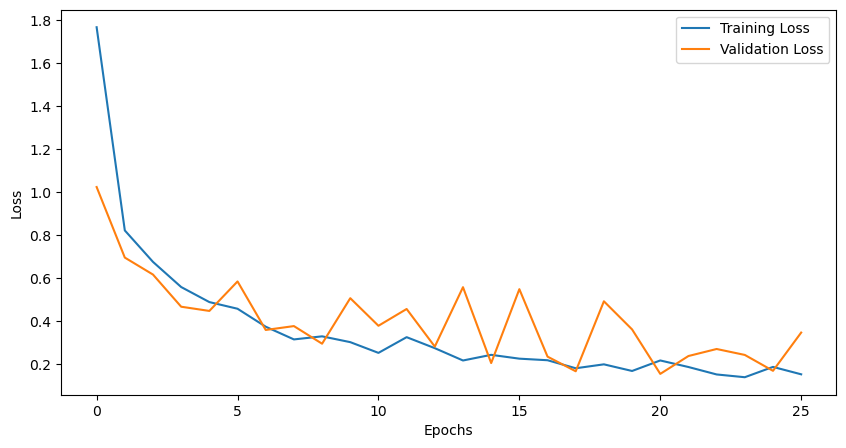

In [68]:
plotAccuracy(historyFineTuned)
plotLoss(historyFineTuned)

We have made an improvement over the 3.2 model, our fine tuning has allowed us to increase our accuracy and decrease loss further. We now are getting an accuracy of `95.81%` and a loss of `17.73%`. This beats our 3.2 model by `0.52` and `2.30` respectively. In addition our classification report comes back with precision of `1.0000` for both Healthy and Anthracnose. Both increased by `5%` each to achieve `100%`.

On the contrary, it seems that the model isn't completely understanding what characteristics can help it identify what fruitfly is. Although it has a `90%` accuracy, it's still a large margin between the others. The model is most likely misclassifying fruitfly with anthracnose, this assumption can be confirmed when we have a further inspection of the predictions by viewing the misclassified images:

In [41]:
def visualiseMisclassifications(model, dataset, target, count):
    # Hardcoded class names
    classes = ['Anthracnose', 'FruitFly', 'Healthy']

    # Rip the images and labels much like the classification function
    datasetImages = []
    datasetLables = []
    
    for images, labels in dataset:
        datasetImages.append(images)
        datasetLables.append(labels)
    
    datasetImages = np.concatenate(datasetImages)
    datasetLables = np.concatenate(datasetLables)
    
    predictions = model.predict(datasetImages)
    predLabels = np.argmax(predictions, axis=1)
    yLabels = np.argmax(datasetLables, axis=1)
    
    # Identify misclassified samples
    misclassified = np.where(predLabels != yLabels)[0]
    
    # Filter for the target class
    filteredMisclassified = []
    for idx in misclassified:
        if yLabels[idx] == classes.index(target):
            filteredMisclassified.append(idx)
    misclassified = filteredMisclassified
    
    # Choose a random selection from the misclassified, sticking to the max count parameter
    selected = np.random.choice(misclassified, size=min(count, len(misclassified)), replace=False)
    
    for prediction in selected:
        plt.imshow(datasetImages[prediction].astype("uint8"))
        plt.title(
            f"True: {classes[yLabels[prediction]]}\n"
            f"Pred: {classes[predLabels[prediction]]}\n"
            f"Confidence: {np.max(predictions[prediction]):.4f}")
        plt.axis("off")
        plt.show()

12/12 [==============================] - 0s 32ms/step


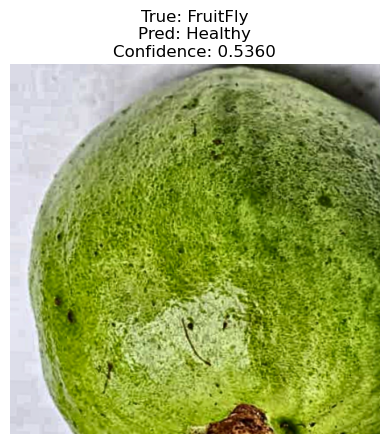

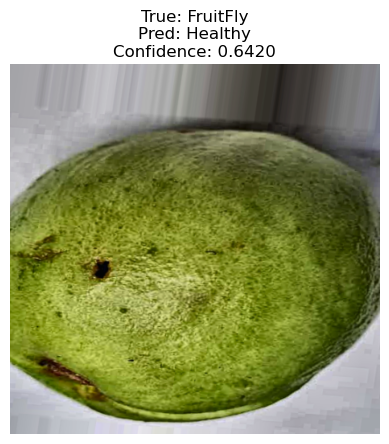

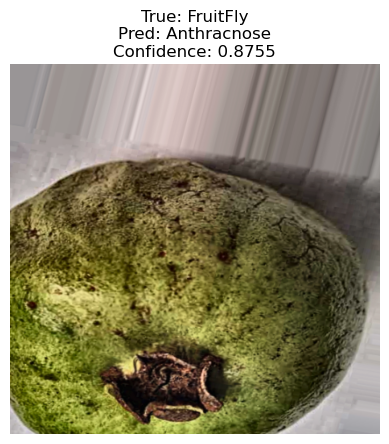

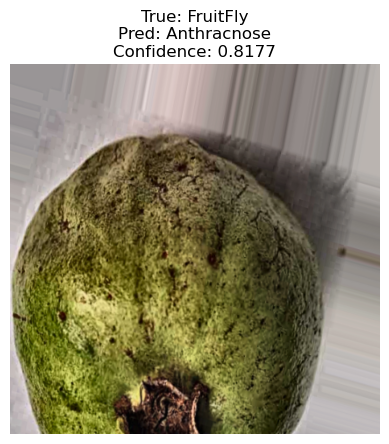

In [128]:
visualiseMisclassifications(fineTuned, testDataset, "FruitFly", 10)

The model struggles with these images. Understandably the model is failing due to the granual detail being mistaken for other patterns.

- Image 1
  - Labelled as FruitFly, the model is assuming the blemishes may be just blemishes and not truly fruitflies, 2 large ones can be seen near the bottom left of the fruit. The confidence displays the model's struggling to fully commit to a 'Healthy' label prediction.
- Image 2
  - Labelled as Healthy but is actually fruitfly, the majority of the fruit is green and ripe however there is a gathering on the far left of the fruit where some fruitflies may be spotted, this could be mistaken for blemishes in the fruit.
- Image 3
  - Labelled as FruitFly but demonstrates no detail of fruitflies on the rotted fruit, model would assume it's diseased.
- Image 4
  - Same explanation as Image 3.
 
These are challenging images from the dataset and ones that visually need some close inspection to truly figure out what is the right label. The solution in mind for this would be to increase granular detail. we have achieved that by:
- Tweaking dropout configurations to reduce any missing data that we missed, although our dropout rate has been fine tuned I doubt this solution would yeild significant improvements.
- A slightly different model configuration which has a bigger influence on nuanced detail.
- We are currently working with 75% of the image resolution, although a jump from 384x384 -> 512x512 would not be enough to iron out this issue as it's still a relatively low resolution image set that can be hard to understand with human eyes.

# **5) FINAL MODEL & FROZEN TRAINED MODELS**

---



*   Complete setup & retraining of the Final model
*   Final model with complex convolution blocks
*   Exploring frozen layer trained models





# 5.1) Complete setup & retraining of the Final model

---



For our complete setup we will go back to the start and start with our datasets and then rework our final model setup

One of the solutions for misclassifications I suggested was to increase the resolution to as far as my local hardware can allow, additionally reducing the batchSize can help reduce any extra overfitting and improve accuracy slightly more.

In [36]:
# Reduce batchSize to 16 to improve accuracy
batchSize = 16
# Boost resolution of images from 75% Native to 90% Native
resolution = int(512 * 0.90)

# Reproduce the datasets with the adjusted resolution and batchSizes
testDataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=(resolution, resolution),
    batch_size=batchSize,
    labels="inferred",
    label_mode="categorical",
)

trainDataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(resolution, resolution),
    batch_size=batchSize,
    labels="inferred",
    label_mode="categorical",
)

valDataset = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=(resolution, resolution),
    batch_size=batchSize,
    labels="inferred",
    label_mode="categorical",
)

# Merge the test and validation
fullTrainDataset = trainDataset.concatenate(valDataset)

Found 382 files belonging to 3 classes.
Found 2647 files belonging to 3 classes.
Found 755 files belonging to 3 classes.


As previously mentioned, the final model has some normalisation layers in each convolution block to aid with stability. To monitor the performance difference we will run the model before and after merging the dataset.

In [27]:
tf.keras.backend.clear_session()

augLayer = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.1)
])

finalModel = tf.keras.models.Sequential()

finalModel.add(tf.keras.layers.Input(shape=(resolution, resolution, 3)))
finalModel.add(augLayer)
finalModel.add(tf.keras.layers.Rescaling(1.0 / 255))

finalModel.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation="relu",))
finalModel.add(tf.keras.layers.MaxPooling2D(pool_size=2))
finalModel.add(tf.keras.layers.Dropout(0.18))

finalModel.add(tf.keras.layers.Conv2D(filters=64, kernel_size=3, activation="relu"))
finalModel.add(tf.keras.layers.MaxPooling2D(pool_size=2))
finalModel.add(tf.keras.layers.Dropout(0.18))

finalModel.add(tf.keras.layers.Conv2D(filters=128, kernel_size=3, activation="relu"))
finalModel.add(tf.keras.layers.MaxPooling2D(pool_size=2))
finalModel.add(tf.keras.layers.Dropout(0.18))

finalModel.add(tf.keras.layers.GlobalAveragePooling2D())
finalModel.add(tf.keras.layers.Dense(128, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.013)))
finalModel.add(tf.keras.layers.Dropout(0.28))
finalModel.add(tf.keras.layers.Dense(3, activation="softmax"))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
finalModel.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

finalModel.summary()

historyFinalModel = finalModel.fit(
    trainDataset,
    epochs=18,
    validation_data=valDataset,
    batch_size=batchSize,
    class_weight=classWeightsDict
)

finalModel.save(str(MODELS_DIR) + "/finalModel.keras")
finalModel = tf.keras.models.load_model(str(MODELS_DIR) + "/finalModel.keras")

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (None, 460, 460, 3)       0         
                                                                 
 rescaling (Rescaling)       (None, 460, 460, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 458, 458, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 229, 229, 32)     0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 229, 229, 32)      0         
                                                                 
 conv2d_1 (Conv2D)           (None, 227, 227, 64)      18496     
                                                      

In [28]:
loss, accuracy = finalModel.evaluate(testDataset, verbose=1)
print(f"Test Loss: {loss:0.4f}")
print(f"Test Accuracy: {accuracy:0.4f}")

24/24 [==============================] - 1s 30ms/step - loss: 0.1458 - accuracy: 0.9607
Test Loss: 0.1458
Test Accuracy: 0.9607


In [29]:
print(getClassificationMetrics(finalModel, testDataset))

12/12 [==============================] - 1s 32ms/step
Class: Anthracnose
Precision: 0.9748
Recall: 0.9936
F1-Score: 0.9841

Class: FruitFly
Precision: 0.9214
Recall: 0.9773
F1-Score: 0.9485

Class: Healthy
Precision: 1.0000
Recall: 0.8830
F1-Score: 0.9379

Macro Average Precision: 0.9654
Macro Average Recall: 0.9513
Macro Average F1-Score: 0.9568
None


This retraining gives us an accuracy of `96.07%` and a loss of `14.58`, we can tell from the metrics that true Healthy is still not accurately being classified, however the model can distinguish what is not Healthy. It is likely the dataset is still suffering from not fully being able to understand the extremely granual blemishes in the dataset, let's see if training on validation helps the model.

In [37]:
tf.keras.backend.clear_session()

augLayer = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.1)
])

finalModel = tf.keras.models.Sequential()

finalModel.add(tf.keras.layers.Input(shape=(resolution, resolution, 3)))
finalModel.add(augLayer)
finalModel.add(tf.keras.layers.Rescaling(1.0 / 255))

finalModel.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation="relu",))
finalModel.add(tf.keras.layers.MaxPooling2D(pool_size=2))
finalModel.add(tf.keras.layers.Dropout(0.18))

finalModel.add(tf.keras.layers.Conv2D(filters=64, kernel_size=3, activation="relu"))
finalModel.add(tf.keras.layers.MaxPooling2D(pool_size=2))
finalModel.add(tf.keras.layers.Dropout(0.18))

finalModel.add(tf.keras.layers.Conv2D(filters=128, kernel_size=3, activation="relu"))
finalModel.add(tf.keras.layers.MaxPooling2D(pool_size=2))
finalModel.add(tf.keras.layers.Dropout(0.18))

finalModel.add(tf.keras.layers.GlobalAveragePooling2D())
finalModel.add(tf.keras.layers.Dense(128, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.013)))
finalModel.add(tf.keras.layers.Dropout(0.28))
finalModel.add(tf.keras.layers.Dense(3, activation="softmax"))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
finalModel.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

finalModel.summary()

historyFinalModel = finalModel.fit(
    fullTrainDataset,
    epochs=18,
    batch_size=batchSize,
    class_weight=classWeightsDict
)

finalModel.save(str(MODELS_DIR) + "/finalModelComplete.keras")
finalModel = tf.keras.models.load_model(str(MODELS_DIR) + "/finalModelComplete.keras")

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (None, 460, 460, 3)       0         
                                                                 
 rescaling (Rescaling)       (None, 460, 460, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 458, 458, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 229, 229, 32)     0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 229, 229, 32)      0         
                                                                 
 conv2d_1 (Conv2D)           (None, 227, 227, 64)      18496     
                                                      

In [38]:
loss, accuracy = finalModel.evaluate(testDataset, verbose=1)
print(f"Test Loss: {loss:0.4f}")
print(f"Test Accuracy: {accuracy:0.4f}")

24/24 [==============================] - 1s 31ms/step - loss: 0.1279 - accuracy: 0.9712
Test Loss: 0.1279
Test Accuracy: 0.9712


In [39]:
print(getClassificationMetrics(finalModel, testDataset))

12/12 [==============================] - 1s 31ms/step
Class: Anthracnose
Precision: 1.0000
Recall: 0.9615
F1-Score: 0.9804

Class: FruitFly
Precision: 0.9231
Recall: 1.0000
F1-Score: 0.9600

Class: Healthy
Precision: 1.0000
Recall: 0.9468
F1-Score: 0.9727

Macro Average Precision: 0.9744
Macro Average Recall: 0.9694
Macro Average F1-Score: 0.9710
None


The complete final model achieves a modest `97.12%` in accuracy and `12.79` for loss. We can also see that Healthy has improved therefore our macro averages across the board have improved. Although we don't achieve 1.0000 precision on all of the classes, our overall performance is marginally higher than the incomplete training set. I believe the increased dataset has allowed for this improvement but misclassification from difficult images are still occuring.

12/12 [==============================] - 1s 33ms/step


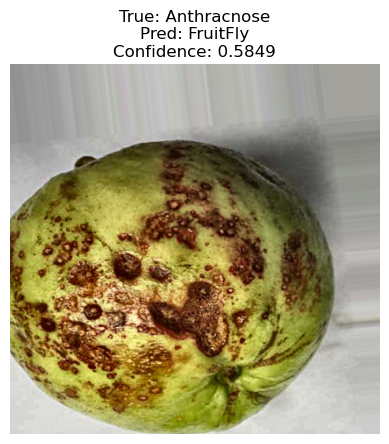

In [42]:
visualiseMisclassifications(finalModel, testDataset, "Anthracnose", 1)

12/12 [==============================] - 0s 32ms/step


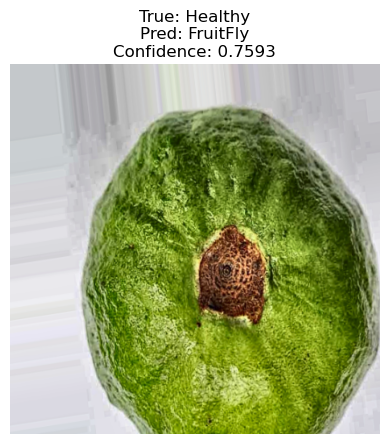

In [43]:
visualiseMisclassifications(finalModel, testDataset, "Healthy", 1)

# 5.2) Final Model with complex convolution blocks

---



One last experiment I want to try for reference is investigating whether a more complex convolution block setup could fill the small margin of error from the final model

Below is a sample of that layer taken from one of the lecture notebooks: 

In [64]:
# CODE SAMPLED FROM: 9.3.modern-convnet-architecture-patterns

def residual_block(x, filters, pooling=False):
    residual = x                                                                 # ← SAVE
    x = tf.keras.layers.Conv2D(filters, 3, activation="relu", padding="same")(x) #   branch 1
    x = tf.keras.layers.Conv2D(filters, 3, activation="relu", padding="same")(x)
    if pooling:
        x = tf.keras.layers.MaxPooling2D(2, padding="same")(x)
        residual = tf.keras.layers.Conv2D(filters, 1, strides=2)(residual)       #   branch 2
    elif filters != residual.shape[-1]:
        residual = tf.keras.layers.Conv2D(filters, 1)(residual)                  #   branch 2
    x = tf.keras.layers.add([x, residual])                                       # ← REINJECT
    return x

We can add our normalisation below our convolution layers as such:

In [144]:
def ResidualBlock(x, filters, pooling=False):
    residual = x 

    # Same convolution layers
    x = tf.keras.layers.Conv2D(filters, 3, activation="relu", padding="same")(x)
    # Batch Normalisation incorporated
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(filters, 3, activation="relu", padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    if pooling:
        x = tf.keras.layers.MaxPooling2D(2, padding="same")(x)
        residual = tf.keras.layers.Conv2D(filters, 1, strides=2)(residual)
    elif filters != residual.shape[-1]:
        residual = tf.keras.layers.Conv2D(filters, 1)(residual)
    # Reinject
    x = tf.keras.layers.add([x, residual])
    return x

The benefit in doing this helps us with both accuracy and stability, batch normalisation aids the stability of the model by preventing dominant values across training. Residual block allow us to retrieve data that was lost or dropped in earlier layers, due to our small image dataset, dropping more and more information without having the dataset quantity to suppliment may be causing our model to prevent reaching its potential.

In [66]:
tf.keras.backend.clear_session()

augLayer = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.1)
])

input = tf.keras.layers.Input(shape=(resolution, resolution, 3))

x = augLayer(input)
x = tf.keras.layers.Rescaling(1.0 / 255)(x)

# Residual replacing our old cov blocks

#.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation="relu",))
#.add(tf.keras.layers.MaxPooling2D(pool_size=2))
#.add(tf.keras.layers.Dropout(0.18))

x = ResidualBlock(x, 32, pooling=True)
x = tf.keras.layers.Dropout(0.18)(x)

x = ResidualBlock(x, 64, pooling=True)
x = tf.keras.layers.Dropout(0.18)(x)

# No pooling here we will pool for the final block
x = ResidualBlock(x, 128, pooling=False)
x = tf.keras.layers.Dropout(0.18)(x)

# Retrain our final block
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.013))(x)
x = tf.keras.layers.Dropout(0.28)(x)
x = tf.keras.layers.Dense(3, activation="softmax")(x)

finalModel2 = tf.keras.models.Model(inputs=input, outputs=x)

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
finalModel2.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

finalModel2.summary()

historyFinalModel2 = finalModel2.fit(
    trainDataset,
    epochs=18,
    validation_data=valDataset,
    batch_size=batchSize,
    class_weight=classWeightsDict
)

finalModel2.save(str(MODELS_DIR) + "/finalModel2.keras")
finalModel2 = tf.keras.models.load_model(str(MODELS_DIR) + "/finalModel2.keras")

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 460, 460, 3  0           []                               
                                )]                                                                
                                                                                                  
 sequential (Sequential)        (None, 460, 460, 3)  0           ['input_1[0][0]']                
                                                                                                  
 rescaling (Rescaling)          (None, 460, 460, 3)  0           ['sequential[0][0]']             
                                                                                                  
 conv2d (Conv2D)                (None, 460, 460, 32  896         ['rescaling[0][0]']          

In [67]:
loss, accuracy = finalModel2.evaluate(testDataset, verbose=1)
print(f"Test Loss: {loss:0.4f}")
print(f"Test Accuracy: {accuracy:0.4f}")

24/24 [==============================] - 2s 53ms/step - loss: 0.1362 - accuracy: 0.9634
Test Loss: 0.1362
Test Accuracy: 0.9634


In [68]:
print(getClassificationMetrics(finalModel2, testDataset))

12/12 [==============================] - 1s 81ms/step
Class: Anthracnose
Precision: 1.0000
Recall: 0.9551
F1-Score: 0.9770

Class: FruitFly
Precision: 0.9407
Recall: 0.9621
F1-Score: 0.9513

Class: Healthy
Precision: 0.9388
Recall: 0.9787
F1-Score: 0.9583

Macro Average Precision: 0.9598
Macro Average Recall: 0.9653
Macro Average F1-Score: 0.9622
None


When comparing to the incomplete final model, this more complex model achieves the same evaluation accuracy of `96.34%` with a slightly higher loss. If we investigate the classification metrics, FruitFly has improved to a more acceptable precision. Regardless of the metrics, both the complex and the less complex final models provide roughly the same performance. One reason for this is because the model lacks sufficient depth to take advantage of the residual blocks, another likely reason comes down to the dataset size.

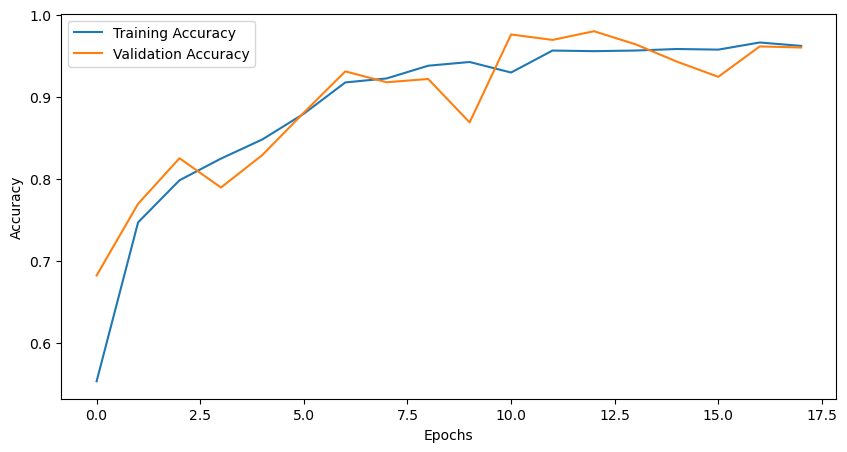

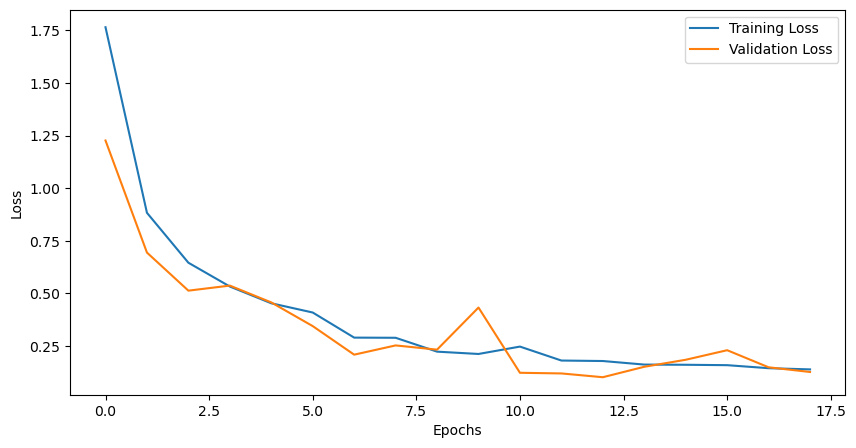

In [73]:
plotAccuracy(historyFinalModel2)
plotLoss(historyFinalModel2)

The model seems to generalise better in this model as the loss doesn't diverge significantly and learning curves for this model are smoother than the one previously. This is a good sign that normalisation did its job as a stabiliser.

Although we have more generalisation, perhaps it's not the best move forward, the model still exhibits the same misclassifications as the previous ones.

12/12 [==============================] - 1s 82ms/step


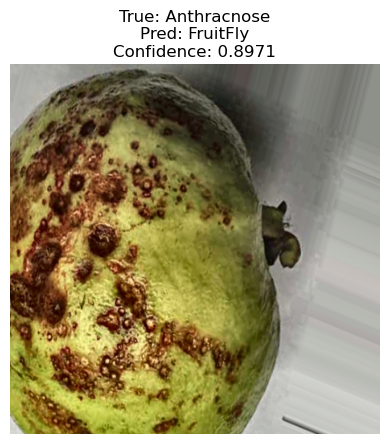

In [138]:
visualiseMisclassifications(finalModel2, testDataset, "Anthracnose", 1)

# 5.3) Exploring a frozen layer trained models

---


One way we can test the strength of the final model is to compare it to pre-trained models, for our examples we will look at some that are already built into keras and don't need to be externally sourced or downloaded outside of this notebook.

One pretrained model we can use is MobileNetV2 which has already been trained on a wide array of images, it is also designed to work well with a small dataset which we have in this case. We also opt to freeze the layer so that it doesn't train and alter its weights based on the guava fruit images we provide which ensures that we can see how a more generalized trained model behaves with our dataset.

In [33]:
tf.keras.backend.clear_session()

pretrainedModel = tf.keras.models.Sequential()
pretrainedModel.add(tf.keras.layers.Input(shape=(resolution, resolution, 3)))
pretrainedModel.add(tf.keras.layers.Rescaling(1.0 / 255))

# Using MobileNetV2 pretrained model
mobileNetLayer = tf.keras.applications.MobileNetV2(weights='imagenet', include_top=False)
# Freeze training
mobileNetLayer.trainable = False
pretrainedModel.add(mobileNetLayer)

pretrainedModel.add(tf.keras.layers.GlobalAveragePooling2D())
pretrainedModel.add(tf.keras.layers.Dense(128, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.013)))
pretrainedModel.add(tf.keras.layers.Dropout(0.28))
pretrainedModel.add(tf.keras.layers.Dense(3, activation="softmax"))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
pretrainedModel.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

pretrainedModel.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_9 (Rescaling)     (None, 460, 460, 3)       0         
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, None, None, 1280)  2257984  
 ional)                                                          
                                                                 
 global_average_pooling2d_7   (None, 1280)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_14 (Dense)            (None, 128)               163968    
                                                                 
 dropout_7 (Dropout)         (None, 128)               0         
                                                                 
 dense_15 (Dense)            (None, 3)                

In [34]:
historyPretrainedModel = pretrainedModel.fit(
    trainDataset,
    # We don't need a large amount of epochs as we anticipate a small amount  of learning
    epochs=10,
    validation_data=valDataset,
    batch_size=batchSize,
    class_weight=classWeightsDict
)

Epoch 1/10
166/166 [==============================] - 17s 85ms/step - loss: 1.9685 - accuracy: 0.8976 - val_loss: 1.0291 - val_accuracy: 0.9642
Epoch 2/10
166/166 [==============================] - 14s 82ms/step - loss: 0.7570 - accuracy: 0.9679 - val_loss: 0.5274 - val_accuracy: 0.9762
Epoch 3/10
166/166 [==============================] - 15s 87ms/step - loss: 0.4275 - accuracy: 0.9804 - val_loss: 0.3333 - val_accuracy: 0.9788
Epoch 4/10
166/166 [==============================] - 15s 87ms/step - loss: 0.2968 - accuracy: 0.9804 - val_loss: 0.2350 - val_accuracy: 0.9854
Epoch 5/10
166/166 [==============================] - 15s 90ms/step - loss: 0.2302 - accuracy: 0.9804 - val_loss: 0.2325 - val_accuracy: 0.9775
Epoch 6/10
166/166 [==============================] - 14s 84ms/step - loss: 0.1899 - accuracy: 0.9807 - val_loss: 0.1632 - val_accuracy: 0.9881
Epoch 7/10
166/166 [==============================] - 14s 86ms/step - loss: 0.1798 - accuracy: 0.9758 - val_loss: 0.1542 - val_accuracy:

In [35]:
loss, accuracy = pretrainedModel.evaluate(testDataset, verbose=1)
print(f"Test Loss: {loss:0.4f}")
print(f"Test Accuracy: {accuracy:0.4f}")

24/24 [==============================] - 2s 60ms/step - loss: 0.1042 - accuracy: 0.9948
Test Loss: 0.1042
Test Accuracy: 0.9948


In [36]:
print(getClassificationMetrics(pretrainedModel, testDataset))

12/12 [==============================] - 2s 91ms/step
Class: Anthracnose
Precision: 1.0000
Recall: 0.9936
F1-Score: 0.9968

Class: FruitFly
Precision: 0.9851
Recall: 1.0000
F1-Score: 0.9925

Class: Healthy
Precision: 1.0000
Recall: 0.9894
F1-Score: 0.9947

Macro Average Precision: 0.9950
Macro Average Recall: 0.9943
Macro Average F1-Score: 0.9946
None


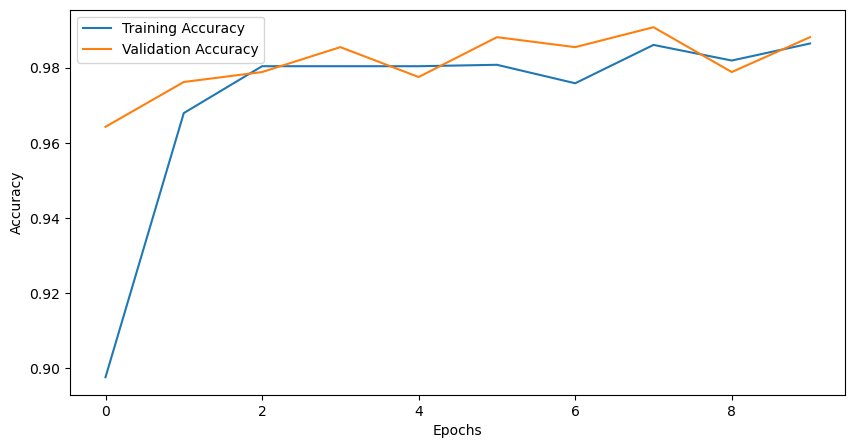

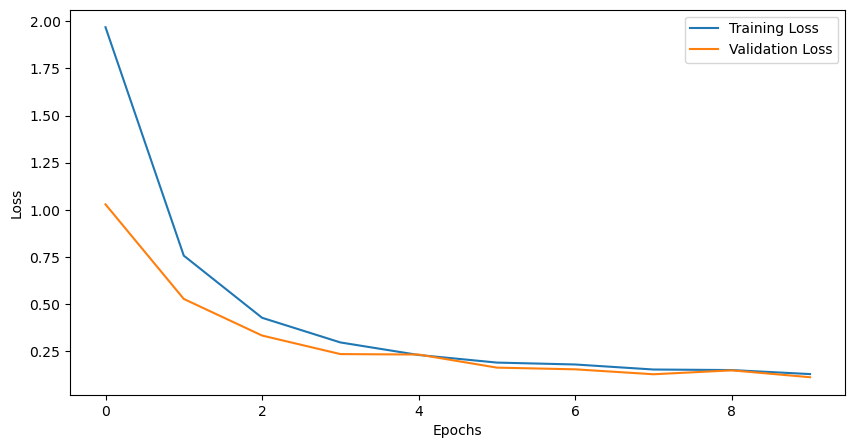

In [37]:
plotAccuracy(historyPretrainedModel)
plotLoss(historyPretrainedModel)

Performance is pretty much perfect, we can see from the graphs that the model is at a robust fit by the end of the training and the metrics score `99%` and higher.

Another pre-trained model we can try is DenseNet121, this model is better at complex pattern recall but it's much better suited to a larger dataset when compared to MobileNetV2

In [24]:
tf.keras.backend.clear_session()

pretrainedModel2 = tf.keras.models.Sequential()
pretrainedModel2.add(tf.keras.layers.Input(shape=(resolution, resolution, 3)))
pretrainedModel2.add(tf.keras.layers.Rescaling(1.0 / 255))

# Using DenseNet121 pretrained model
denseNetLayer = tf.keras.applications.DenseNet121(weights='imagenet', include_top=False)
denseNetLayer.trainable = False
pretrainedModel2.add(denseNetLayer)

pretrainedModel2.add(tf.keras.layers.GlobalAveragePooling2D())
pretrainedModel2.add(tf.keras.layers.Dense(128, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.013)))
pretrainedModel2.add(tf.keras.layers.Dropout(0.28))
pretrainedModel2.add(tf.keras.layers.Dense(3, activation="softmax"))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
pretrainedModel2.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

pretrainedModel2.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 460, 460, 3)       0         
                                                                 
 densenet121 (Functional)    (None, None, None, 1024)  7037504   
                                                                 
 global_average_pooling2d (G  (None, 1024)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 128)               131200    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 3)                 387       
                                                        

In [25]:
historyPretrainedModel2 = pretrainedModel2.fit(
    trainDataset,
    epochs=10,
    validation_data=valDataset,
    batch_size=batchSize,
    class_weight=classWeightsDict
)

Epoch 1/10
166/166 [==============================] - 30s 154ms/step - loss: 1.7018 - accuracy: 0.8882 - val_loss: 0.7749 - val_accuracy: 0.9709
Epoch 2/10
166/166 [==============================] - 24s 144ms/step - loss: 0.6048 - accuracy: 0.9728 - val_loss: 0.4509 - val_accuracy: 0.9801
Epoch 3/10
166/166 [==============================] - 24s 143ms/step - loss: 0.3950 - accuracy: 0.9754 - val_loss: 0.3234 - val_accuracy: 0.9815
Epoch 4/10
166/166 [==============================] - 24s 144ms/step - loss: 0.2815 - accuracy: 0.9841 - val_loss: 0.2290 - val_accuracy: 0.9921
Epoch 5/10
166/166 [==============================] - 24s 144ms/step - loss: 0.2205 - accuracy: 0.9826 - val_loss: 0.1811 - val_accuracy: 0.9921
Epoch 6/10
166/166 [==============================] - 24s 144ms/step - loss: 0.1841 - accuracy: 0.9872 - val_loss: 0.1563 - val_accuracy: 0.9881
Epoch 7/10
166/166 [==============================] - 24s 143ms/step - loss: 0.1639 - accuracy: 0.9864 - val_loss: 0.1557 - val_ac

In [26]:
loss, accuracy = pretrainedModel2.evaluate(testDataset, verbose=1)
print(f"Test Loss: {loss:0.4f}")
print(f"Test Accuracy: {accuracy:0.4f}")

24/24 [==============================] - 3s 111ms/step - loss: 0.1025 - accuracy: 0.9974
Test Loss: 0.1025
Test Accuracy: 0.9974


In [27]:
print(getClassificationMetrics(pretrainedModel2, testDataset))

12/12 [==============================] - 4s 196ms/step
Class: Anthracnose
Precision: 0.9936
Recall: 1.0000
F1-Score: 0.9968

Class: FruitFly
Precision: 1.0000
Recall: 0.9924
F1-Score: 0.9962

Class: Healthy
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000

Macro Average Precision: 0.9979
Macro Average Recall: 0.9975
Macro Average F1-Score: 0.9977
None


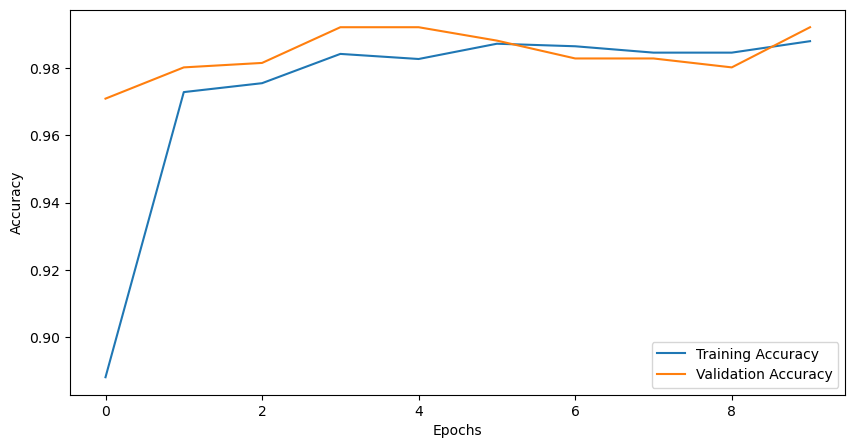

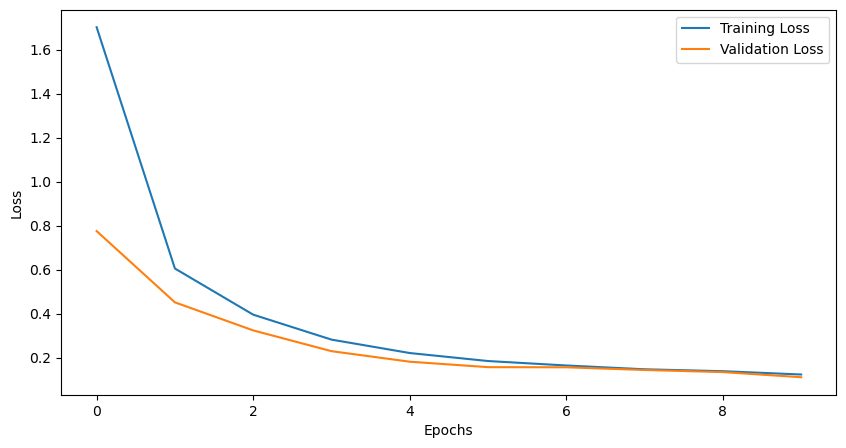

In [28]:
plotAccuracy(historyPretrainedModel2)
plotLoss(historyPretrainedModel2)

It seems that when running for the same amount of epochs and same parameters, DenseNet performs just as good and marginally better than MobileNetV2.

Although the metrics for these pretrained models are extremely strong with almost `100%` accuracy, we can still see that they suffer from the same classification issues as my final model. This exemplifies the final model's robustness as it can predict similarly to much more well trained ones.

12/12 [==============================] - 7s 322ms/step


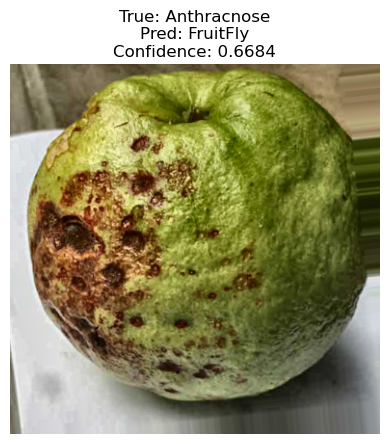

In [143]:
visualiseMisclassifications(pretrainedModel2, testDataset, "Anthracnose", 1)

# **CONCLUSION**

---





This project aimed to classify guava fruit images into three categories: healthy, diseased, and fruit-fly-infected. I crafted a strong suitable model that performs nearly as good as complex pretrained models. Through systematic experimentation and optimization, I achieved a high accuracy of `97.12%`. This outcome reflects the quantitative analysis I documented from a simple model to the final one through my understanding of which classes the model struggled with and why.

Further prediction improvements I would make would be to increase the dataset count as it's been an underpinning constraint for this report. I would also involve some readjustments of the dataset, it's clear that some images, although hard to clearly distinguish, could use enhancements to focal characteristics to allow the models to fully understand what it should be looking for when deciding predictions.
